# Phase 0: Exploratory Data Analysis

## LA Kelp Detection - BC Sentinel-2 & Figshare Landsat Datasets

This notebook explores:
1. **BC Sentinel-2** - 12-band tiles (512×512) with kelp segmentation masks
2. **Figshare Landsat** - RGB images with VIA polygon annotations

---

In [1]:
# Imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import rasterio
from rasterio.plot import show
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 400

# Paths
ROOT = Path('/Users/ebisong/Documents/code/uvic/thesis')
BC_DATA = ROOT / 'data' / 'bc_sentinel2' / 'new'
FIGSHARE_DATA = ROOT / 'data' / 'figshare_landsat'
OUTPUT_DIR = ROOT / 'results' / 'raw' / 'phase_0_eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BC Data: {BC_DATA}")
print(f"Figshare Data: {FIGSHARE_DATA}")
print(f"Output: {OUTPUT_DIR}")

BC Data: /Users/ebisong/Documents/code/uvic/thesis/data/bc_sentinel2/new
Figshare Data: /Users/ebisong/Documents/code/uvic/thesis/data/figshare_landsat
Output: /Users/ebisong/Documents/code/uvic/thesis/results/raw/phase_0_eda


---
## 1. BC Sentinel-2 Dataset

### 1.1 Load Manifest & Overview

In [2]:
# Load manifest
with open(ROOT / 'data' / 'bc_sentinel2' / 'data_manifest.json') as f:
    manifest = json.load(f)

# Display summary
print("=== BC Sentinel-2 Dataset Summary ===")
print(f"Total Scenes: {manifest['summary']['total_scenes']}")
print(f"Total Tiles: {manifest['summary']['total_tiles']}")
print(f"Date Range: {manifest['summary']['date_range']}")
print(f"UTM Zones: {manifest['summary']['utm_zones']}")
print()

# Create scenes DataFrame
scenes_df = pd.DataFrame(manifest['scenes'])
scenes_df['acquisition_date'] = pd.to_datetime(scenes_df['acquisition_date'])
scenes_df

=== BC Sentinel-2 Dataset Summary ===
Total Scenes: 10
Total Tiles: 1045
Date Range: ['2020-09-08', '2023-09-02']
UTM Zones: ['9N', '10N']



,scene_id,site_code,acquisition_date,utm_zone,n_tiles,status,notes
0,20200908T192939_20200908T193355_T09UWS,T09UWS,2020-09-08,9N,228,complete,NaN
1,20200908T192939_20200908T193355_T09UXR,T09UXR,2020-09-08,9N,159,complete,NaN
2,20210727T191911_20210727T192721_T09UXQ,T09UXQ,2021-07-27,9N,45,complete,NaN
3,20220806T191919_20220806T192707_T09UYQ,T09UYQ,2022-08-06,9N,121,complete,NaN
4,20220806T191919_20220806T192707_T10UCU,T10UCU,2022-08-06,10N,63,complete,NaN
5,20230804T192909_20230804T192942_T09UXS,T09UXS,2023-08-04,9N,105,complete,NaN
6,20230816T191911_20230816T192348_T10UCA,T10UCA,2023-08-16,10N,70,complete,NaN
7,20230819T192911_20230819T193100_T09UWT,T09UWT,2023-08-19,9N,48,complete,NaN
8,20230902T190921_20230902T191805_T10UDU,T10UDU,2023-09-02,10N,181,complete,NaN
9,20230902T195919_20230902T195917_T09UUU,T09UUU,2023-09-02,9N,25,complete,Merged 9 additional tiles from old/ directory


### 1.2 Load Sample Tiles & Visualize

In [3]:
def load_tile(tile_path):
    """Load a 12-band tile using rasterio"""
    with rasterio.open(tile_path) as src:
        data = src.read()  # Shape: (bands, H, W)
        meta = src.meta
    return data, meta

def load_mask(mask_path):
    """Load a binary mask"""
    with rasterio.open(mask_path) as src:
        mask = src.read(1)  # Shape: (H, W)
    return mask

def normalize_rgb(rgb_bands, percentile=98):
    """Normalize RGB bands for visualization"""
    rgb = np.stack(rgb_bands, axis=-1)
    p_low = np.percentile(rgb, 100 - percentile)
    p_high = np.percentile(rgb, percentile)
    rgb_norm = np.clip((rgb - p_low) / (p_high - p_low), 0, 1)
    return rgb_norm

# Load one sample tile from first scene
tiles_dir = BC_DATA / 'Tiles 10 Scenes'
sample_scene = list(tiles_dir.iterdir())[0]
sample_tile_path = list((sample_scene / 'images').glob('*.tiff'))[0]
sample_mask_path = list((sample_scene / 'masks').glob('*.tiff'))[0]

print(f"Loading sample tile: {sample_tile_path.name}")
tile_data, tile_meta = load_tile(sample_tile_path)
mask_data = load_mask(sample_mask_path)

print(f"Tile shape: {tile_data.shape}")
print(f"Tile dtype: {tile_data.dtype}")
print(f"Mask shape: {mask_data.shape}")
print(f"Mask unique values: {np.unique(mask_data)}")

Loading sample tile: tile_98_image.tiff


Tile shape: (12, 512, 512)
Tile dtype: float32
Mask shape: (512, 512)
Mask unique values: [0 1]


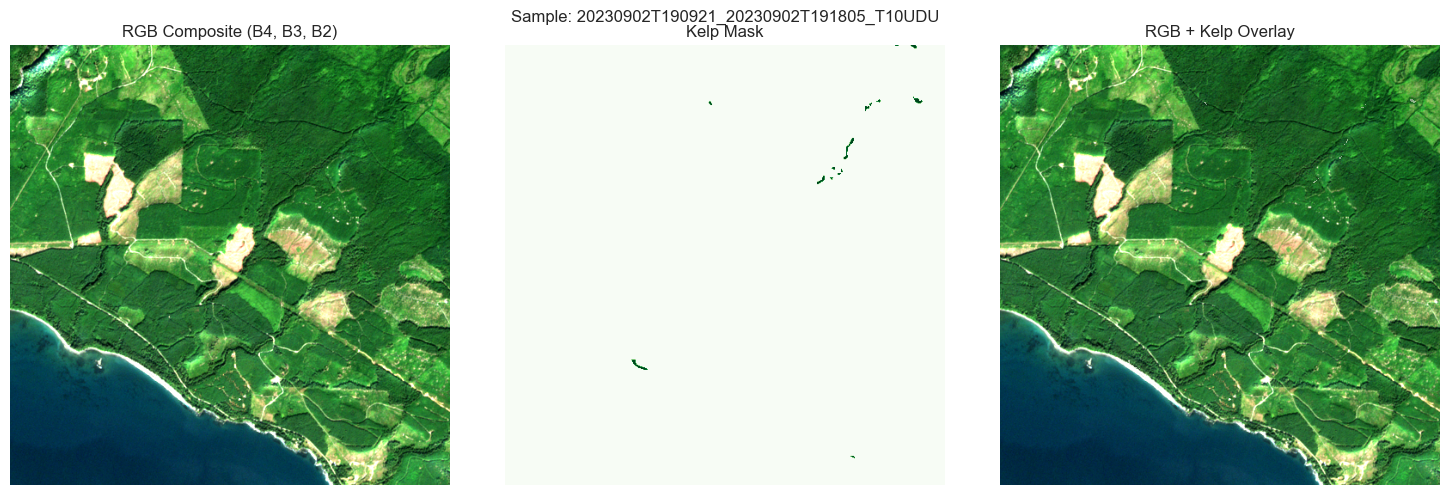

In [4]:
# Visualize sample tile: RGB composite + mask overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RGB composite (bands 4, 3, 2 -> indices 2, 1, 0)
rgb = normalize_rgb([tile_data[2], tile_data[1], tile_data[0]])

axes[0].imshow(rgb)
axes[0].set_title('RGB Composite (B4, B3, B2)')
axes[0].axis('off')

# Mask
axes[1].imshow(mask_data, cmap='Greens')
axes[1].set_title('Kelp Mask')
axes[1].axis('off')

# Overlay
axes[2].imshow(rgb)
mask_overlay = np.ma.masked_where(mask_data == 0, mask_data)
axes[2].imshow(mask_overlay, cmap='Reds', alpha=0.5)
axes[2].set_title('RGB + Kelp Overlay')
axes[2].axis('off')

plt.suptitle(f'Sample: {sample_tile_path.parent.parent.name}', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_tile_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Band Statistics Analysis

In [5]:
# Analyze band statistics across multiple tiles
band_names = ['B2', 'B3', 'B4', 'B8', 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12', 'Substrate', 'Bathymetry']

def collect_band_stats(tiles_dir, n_samples=5):
    """Collect band statistics from sampled tiles across all scenes"""
    stats = defaultdict(list)
    
    for scene_dir in tiles_dir.iterdir():
        if not scene_dir.is_dir():
            continue
        
        images_dir = scene_dir / 'images'
        if not images_dir.exists():
            continue
            
        tile_files = list(images_dir.glob('*.tiff'))[:n_samples]
        
        for tile_path in tile_files:
            tile_data, _ = load_tile(tile_path)
            
            for i, band_name in enumerate(band_names):
                band = tile_data[i]
                valid = band[band != 0]  # Exclude nodata
                if len(valid) > 0:
                    stats[band_name].extend([
                        {'scene': scene_dir.name, 'mean': valid.mean(), 'std': valid.std(),
                         'min': valid.min(), 'max': valid.max()}
                    ])
    
    return stats

print("Collecting band statistics (sampling 5 tiles per scene)...")
band_stats = collect_band_stats(tiles_dir, n_samples=5)

# Create summary DataFrame
stats_summary = []
for band_name in band_names:
    band_data = band_stats[band_name]
    if band_data:
        means = [d['mean'] for d in band_data]
        stats_summary.append({
            'band': band_name,
            'mean': np.mean(means),
            'std': np.std(means),
            'min': min([d['min'] for d in band_data]),
            'max': max([d['max'] for d in band_data])
        })

stats_df = pd.DataFrame(stats_summary)
stats_df

,band,mean,std,min,max
0,B2,194.692810,44.004864,1.0,10448.000000
1,B3,270.218872,90.358505,1.0,16152.000000
2,B4,145.518494,64.977608,1.0,12536.000000
3,B8,1155.492065,855.417175,1.0,15608.000000
4,B5,353.888794,220.888092,1.0,6533.000000
5,B6,929.851013,675.397217,1.0,7305.000000
6,B7,1083.183716,808.790894,1.0,8351.000000
7,B8A,1211.727295,899.747437,1.0,8840.000000
8,B11,490.722931,351.875275,1.0,11029.000000
9,B12,241.398972,165.444565,1.0,7107.000000


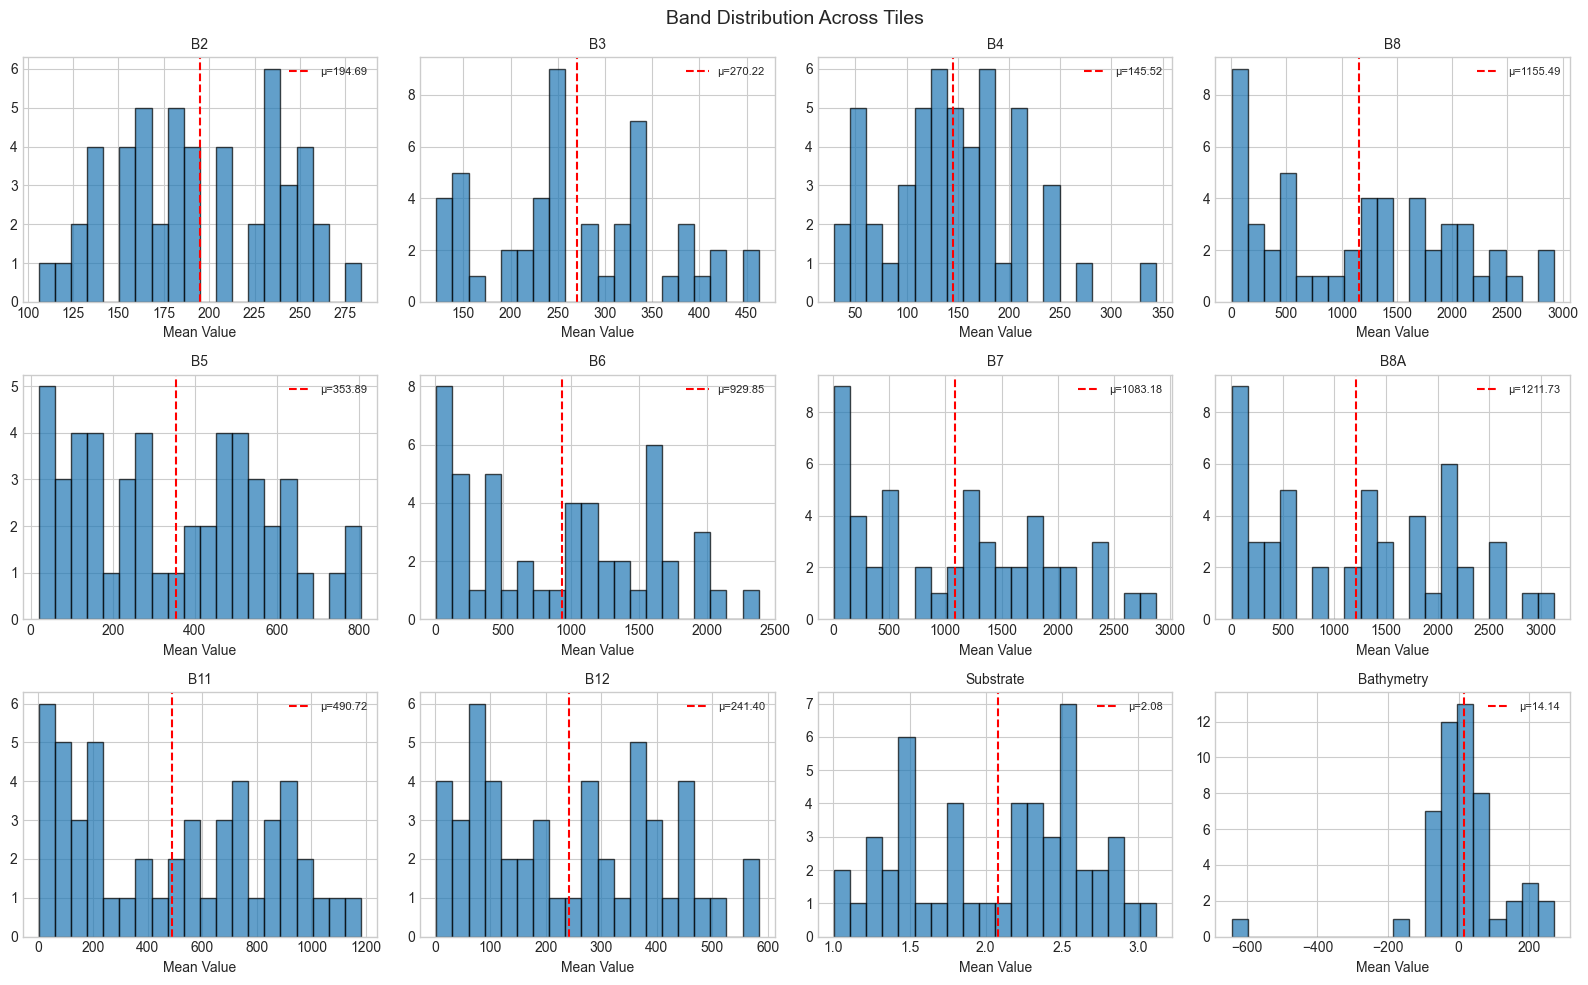

In [6]:
# Visualize band distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, band_name in enumerate(band_names):
    ax = axes[i]
    means = [d['mean'] for d in band_stats[band_name]]
    ax.hist(means, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(f'{band_name}', fontsize=10)
    ax.set_xlabel('Mean Value')
    ax.axvline(np.mean(means), color='red', linestyle='--', label=f'μ={np.mean(means):.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Band Distribution Across Tiles', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'band_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Kelp Prevalence Analysis

In [7]:
def calculate_kelp_prevalence(tiles_dir):
    """Calculate kelp pixel percentage per scene"""
    prevalence = []
    
    for scene_dir in tiles_dir.iterdir():
        if not scene_dir.is_dir():
            continue
        
        masks_dir = scene_dir / 'masks'
        if not masks_dir.exists():
            continue
        
        total_pixels = 0
        kelp_pixels = 0
        
        for mask_path in masks_dir.glob('*.tiff'):
            mask = load_mask(mask_path)
            total_pixels += mask.size
            kelp_pixels += np.sum(mask == 1)
        
        if total_pixels > 0:
            prevalence.append({
                'scene': scene_dir.name.split('_')[-1],  # Extract site code
                'total_pixels': total_pixels,
                'kelp_pixels': kelp_pixels,
                'kelp_pct': (kelp_pixels / total_pixels) * 100
            })
    
    return pd.DataFrame(prevalence)

print("Calculating kelp prevalence per scene...")
prevalence_df = calculate_kelp_prevalence(tiles_dir)
prevalence_df = prevalence_df.sort_values('kelp_pct', ascending=False)
prevalence_df

Calculating kelp prevalence per scene...


,scene,total_pixels,kelp_pixels,kelp_pct
1,T09UWT,12582912,211961,1.684515
9,T09UXS,27525120,425389,1.545457
2,T09UXQ,11796480,173872,1.473931
3,T09UWS,59768832,698352,1.168422
8,T09UXR,41680896,376264,0.902725
0,T10UDU,47448064,286843,0.604541
4,T09UUU,6553600,37464,0.571655
7,T10UCU,16515072,91008,0.551060
5,T09UYQ,31719424,150847,0.475567
6,T10UCA,18350080,39854,0.217187


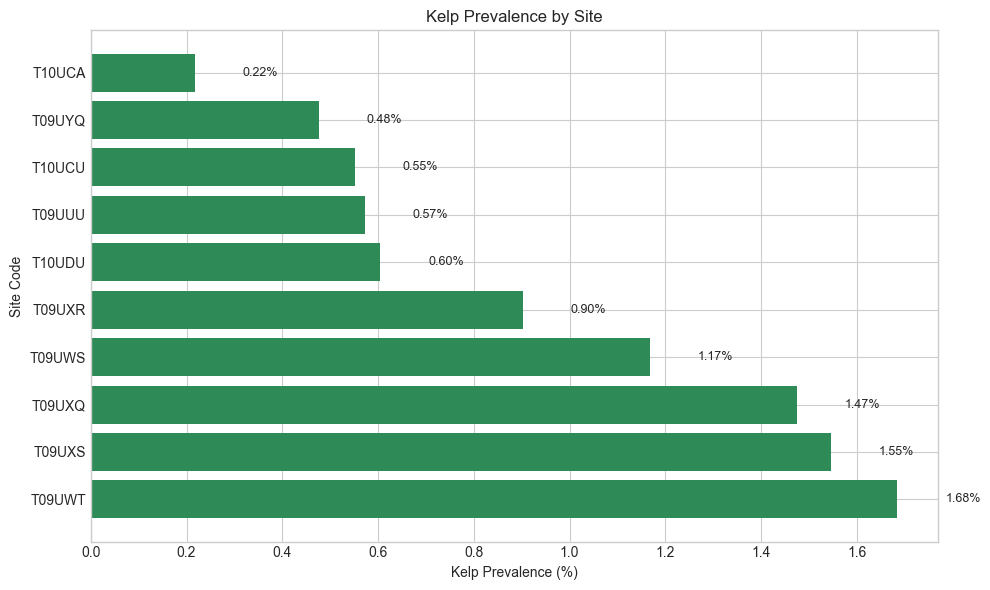

In [8]:
# Visualize kelp prevalence
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prevalence_df['scene'], prevalence_df['kelp_pct'], color='seagreen')
ax.set_xlabel('Kelp Prevalence (%)')
ax.set_ylabel('Site Code')
ax.set_title('Kelp Prevalence by Site')

# Add value labels
for bar, pct in zip(bars, prevalence_df['kelp_pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kelp_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Auxiliary Layer Validation

In [9]:
# Check auxiliary layers in Masks directory
masks_dir = BC_DATA / 'Masks 10 scenes'

if masks_dir.exists():
    print("=== Auxiliary Layers Check ===")
    for scene_dir in sorted(masks_dir.iterdir()):
        if not scene_dir.is_dir():
            continue
        
        files = list(scene_dir.glob('*.tif'))
        site = scene_dir.name.split('_')[-1]
        
        bath = any('Bathymetry' in f.name for f in files)
        sub = any('Substrate' in f.name for f in files)
        mask = any('Mask' in f.name and 'Tile' not in f.name for f in files)
        
        status = "✓" if (bath and sub and mask) else "✗"
        print(f"{status} {site}: Bathymetry={bath}, Substrate={sub}, Mask={mask}")
else:
    print("Masks directory not found")

=== Auxiliary Layers Check ===
✓ T09UWS: Bathymetry=True, Substrate=True, Mask=True
✓ T09UXR: Bathymetry=True, Substrate=True, Mask=True
✓ T09UXQ: Bathymetry=True, Substrate=True, Mask=True
✓ T09UYQ: Bathymetry=True, Substrate=True, Mask=True
✓ T10UCU: Bathymetry=True, Substrate=True, Mask=True
✓ T09UXS: Bathymetry=True, Substrate=True, Mask=True
✓ T10UCA: Bathymetry=True, Substrate=True, Mask=True
✓ T09UWT: Bathymetry=True, Substrate=True, Mask=True
✗ T10UDU: Bathymetry=False, Substrate=False, Mask=True


In [10]:
# Visualize auxiliary layers for one scene
if masks_dir.exists():
    sample_scene_mask = list(masks_dir.iterdir())[0]
    
    bath_path = list(sample_scene_mask.glob('*_Bathymetry.tif'))
    sub_path = list(sample_scene_mask.glob('*_Substrate.tif'))
    
    if bath_path and sub_path:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        with rasterio.open(bath_path[0]) as src:
            bath = src.read(1)
            im0 = axes[0].imshow(bath, cmap='viridis')
            axes[0].set_title('Bathymetry')
            plt.colorbar(im0, ax=axes[0], label='Depth (m)')
        
        with rasterio.open(sub_path[0]) as src:
            sub = src.read(1)
            im1 = axes[1].imshow(sub, cmap='tab10')
            axes[1].set_title('Substrate')
            plt.colorbar(im1, ax=axes[1], label='Class')
        
        plt.suptitle(f'Auxiliary Layers: {sample_scene_mask.name}', fontsize=12)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'auxiliary_layers.png', dpi=150, bbox_inches='tight')
        plt.show()

---
## 2. Figshare Landsat Dataset

### 2.1 Dataset Overview

In [11]:
# Load VIA annotations
def load_via_annotations(json_path):
    """Load and parse VIA JSON annotations"""
    with open(json_path) as f:
        data = json.load(f)
    return data

# Count images and annotations per split
splits = ['train', 'val', 'test']
split_stats = []

for split in splits:
    split_dir = FIGSHARE_DATA / split
    if not split_dir.exists():
        continue
    
    # Filter out hidden macOS files (._*)
    images = [f for f in split_dir.glob('*.jpg') if not f.name.startswith('._')]
    via_path = split_dir / 'via_region_data.json'
    
    n_annotations = 0
    if via_path.exists():
        via_data = load_via_annotations(via_path)
        n_annotations = sum(len(v.get('regions', [])) for v in via_data.values())
    
    split_stats.append({
        'split': split,
        'n_images': len(images),
        'n_annotations': n_annotations
    })

split_df = pd.DataFrame(split_stats)
split_df['total'] = split_df['n_images'].sum()
print("=== Figshare Landsat Dataset ===")
split_df

=== Figshare Landsat Dataset ===


,split,n_images,n_annotations,total
0,train,317,2368,421
1,val,30,440,421
2,test,74,537,421


In [12]:
# Analyze image naming conventions (Landsat 5 vs 8)
# Filter out hidden macOS files (._*)
train_images = [f for f in (FIGSHARE_DATA / 'train').glob('*.jpg') if not f.name.startswith('._')]

landsat_versions = defaultdict(int)
for img in train_images:
    name = img.stem
    if name.startswith('LC08'):
        landsat_versions['Landsat 8'] += 1
    elif name.startswith('LT05'):
        landsat_versions['Landsat 5'] += 1
    else:
        landsat_versions['Unknown'] += 1

print("Landsat Version Distribution (train set):")
for version, count in landsat_versions.items():
    print(f"  {version}: {count} images")

Landsat Version Distribution (train set):
  Landsat 8: 152 images
  Landsat 5: 165 images


### 2.2 Sample Image Visualization

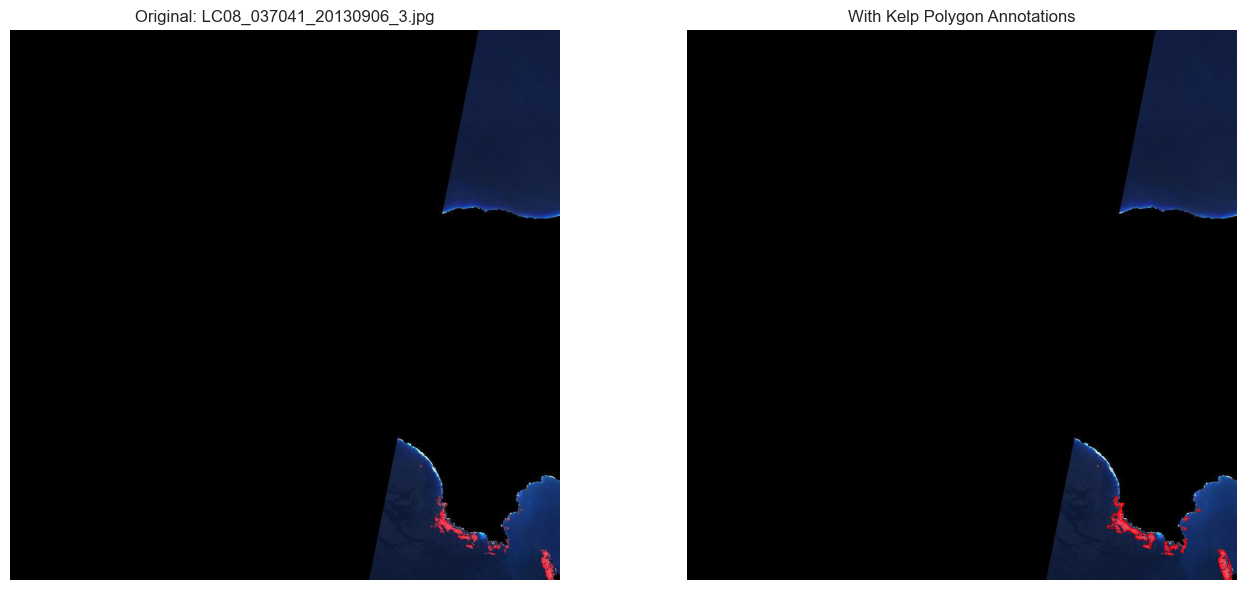

In [13]:
from PIL import ImageDraw

def draw_via_polygons(img, regions):
    """Draw VIA polygon annotations on image"""
    img_draw = img.copy()
    draw = ImageDraw.Draw(img_draw)
    
    for region in regions:
        shape = region.get('shape_attributes', {})
        if shape.get('name') == 'polygon':
            points_x = shape.get('all_points_x', [])
            points_y = shape.get('all_points_y', [])
            if points_x and points_y:
                polygon = list(zip(points_x, points_y))
                draw.polygon(polygon, outline='red', width=2)
    
    return img_draw

# Load sample image with annotations
train_dir = FIGSHARE_DATA / 'train'
via_path = train_dir / 'via_region_data.json'

if via_path.exists():
    via_data = load_via_annotations(via_path)
    
    # Find image with annotations
    for key, value in via_data.items():
        if value.get('regions'):
            filename = value['filename']
            img_path = train_dir / filename
            if img_path.exists():
                img = Image.open(img_path)
                img_annotated = draw_via_polygons(img, value['regions'])
                
                fig, axes = plt.subplots(1, 2, figsize=(14, 6))
                axes[0].imshow(img)
                axes[0].set_title(f'Original: {filename}')
                axes[0].axis('off')
                
                axes[1].imshow(img_annotated)
                axes[1].set_title('With Kelp Polygon Annotations')
                axes[1].axis('off')
                
                plt.tight_layout()
                plt.savefig(OUTPUT_DIR / 'figshare_sample.png', dpi=150, bbox_inches='tight')
                plt.show()
                break

### 2.3 Image Dimensions Analysis

In [14]:
# Analyze image dimensions
dimensions = []
for split in splits:
    split_dir = FIGSHARE_DATA / split
    # Filter out hidden macOS files (._*) and sample 50
    valid_images = [f for f in split_dir.glob('*.jpg') if not f.name.startswith('._')][:50]
    for img_path in valid_images:
        with Image.open(img_path) as img:
            dimensions.append({
                'split': split,
                'width': img.width,
                'height': img.height,
                'aspect_ratio': img.width / img.height
            })

dim_df = pd.DataFrame(dimensions)
print("=== Image Dimensions ===")
print(dim_df.groupby('split').agg({
    'width': ['min', 'max', 'mean'],
    'height': ['min', 'max', 'mean']
}))

=== Image Dimensions ===
      width               height              
        min   max    mean    min   max    mean
split                                         
test   1024  1024  1024.0   1024  1024  1024.0
train  1024  1024  1024.0   1024  1024  1024.0
val    1024  1024  1024.0   1024  1024  1024.0


---
## 3. Dataset Comparison

### 3.1 BC RGB vs Figshare RGB

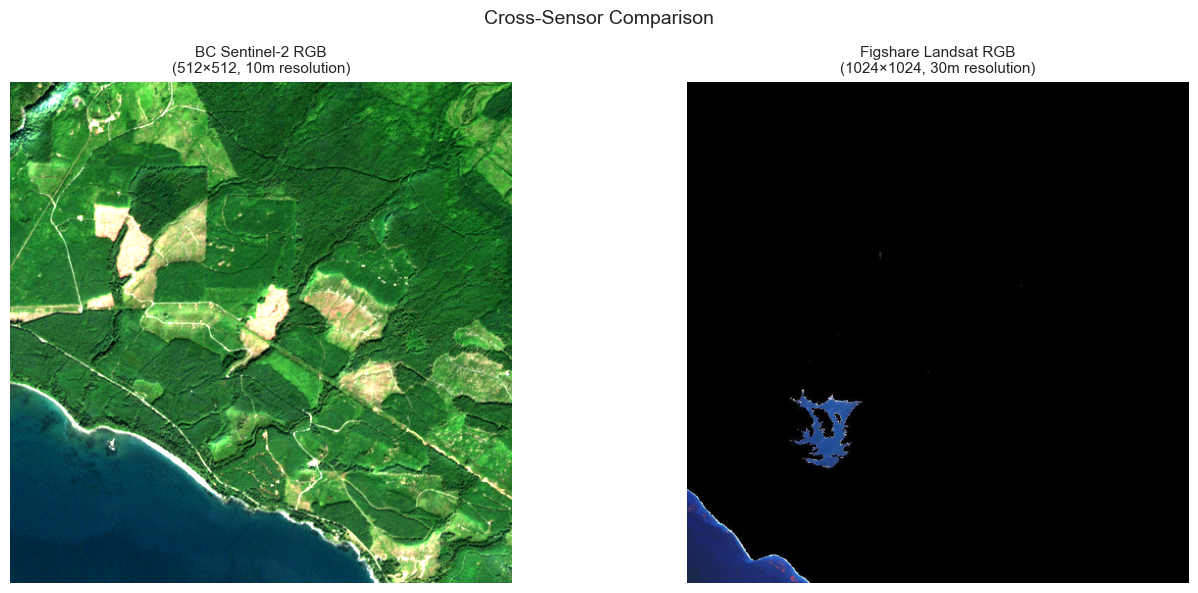

In [15]:
# Compare RGB characteristics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BC Sentinel-2 RGB
axes[0].imshow(rgb)
axes[0].set_title(f'BC Sentinel-2 RGB\n(512×512, 10m resolution)', fontsize=11)
axes[0].axis('off')

# Figshare Landsat RGB
if train_images:
    fig_img = Image.open(train_images[0])
    axes[1].imshow(fig_img)
    axes[1].set_title(f'Figshare Landsat RGB\n({fig_img.width}×{fig_img.height}, 30m resolution)', fontsize=11)
    axes[1].axis('off')

plt.suptitle('Cross-Sensor Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_sensor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Critical Analysis: BC Sentinel-2 Dataset

### SWOT Analysis & Investigative Assessment

In [16]:
# =============================================================================
# BC SENTINEL-2 DATASET: SWOT ANALYSIS
# =============================================================================

# Load site locations for geographic context
with open(ROOT / 'data' / 'bc_sentinel2' / 'site_locations.json') as f:
    site_locations = json.load(f)

# Calculate additional statistics for analysis
total_kelp_pixels = prevalence_df['kelp_pixels'].sum()
total_pixels = prevalence_df['total_pixels'].sum()
overall_kelp_pct = (total_kelp_pixels / total_pixels) * 100

# Temporal distribution
scenes_df['year'] = scenes_df['acquisition_date'].dt.year
scenes_df['month'] = scenes_df['acquisition_date'].dt.month

print("="*80)
print("BC SENTINEL-2: DETAILED SWOT ANALYSIS")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                              STRENGTHS                                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  S1. MULTI-SPECTRAL RICHNESS (12 bands)                                      ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 10 spectral bands capturing visible, NIR, and SWIR wavelengths            ║
║  • Red-edge bands (B5, B6, B7) critical for vegetation discrimination        ║
║  • NIR bands (B8, B8A) enable NDVI-style kelp indices                        ║
║  • SWIR bands (B11, B12) help distinguish kelp from water/sediment           ║
║  • WHY THIS MATTERS: Kelp has unique spectral signatures in red-edge and     ║
║    NIR regions that RGB alone cannot capture. This enables spectral indices  ║
║    like NDVI, FAI (Floating Algae Index), and custom kelp indices.           ║
║                                                                              ║
║  S2. INTEGRATED AUXILIARY DATA                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Bathymetry layer: -2000m to +890m range (depth/elevation)                 ║
║  • Substrate layer: 4-class categorical (rock, sand, mud, mixed?)            ║
║  • Pre-fused with imagery at same resolution (no resampling needed)          ║
║  • WHY THIS MATTERS: Kelp attachment depends heavily on substrate type       ║
║    (prefers rocky substrate) and depth (typically 0-30m). This contextual    ║
║    data enables the LA framework to learn environment-heuristic mappings.    ║
║                                                                              ║
║  S3. HIGH SPATIAL RESOLUTION                                                 ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 10m native resolution for RGB and NIR bands                               ║
║  • 512×512 tile size = 5.12km × 5.12km ground coverage per tile              ║
║  • Sufficient to resolve individual kelp canopies                            ║
║  • WHY THIS MATTERS: Bull kelp canopies typically span 1-10m, making 10m     ║
║    resolution adequate for detection (though not individual frond mapping).  ║
║                                                                              ║
║  S4. GEOGRAPHIC COVERAGE OF BC COAST                                         ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 10 sites spanning ~500km of coastline (Victoria to Haida Gwaii)           ║
║  • Covers multiple ecological zones: exposed outer coast, protected inlets   ║
║  • Includes Clayoquot Sound UNESCO Biosphere Reserve                         ║
║  • WHY THIS MATTERS: Tests LA framework's ability to generalize across       ║
║    heterogeneous environments - a core thesis objective (RQ2).               ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Print actual statistics
print("\n>>> STRENGTH STATISTICS:")
print(f"    • Total tiles: {manifest['summary']['total_tiles']}")
print(f"    • Bands available: {len(band_names)} (10 spectral + 2 auxiliary)")
print(f"    • Geographic extent: {site_locations['geographic_coverage']['extent_km']['description']}")
print(f"    • Sites covered: {len(site_locations['sites'])}")

BC SENTINEL-2: DETAILED SWOT ANALYSIS

╔══════════════════════════════════════════════════════════════════════════════╗
║                              STRENGTHS                                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  S1. MULTI-SPECTRAL RICHNESS (12 bands)                                      ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 10 spectral bands capturing visible, NIR, and SWIR wavelengths            ║
║  • Red-edge bands (B5, B6, B7) critical for vegetation discrimination        ║
║  • NIR bands (B8, B8A) enable NDVI-style kelp indices                        ║
║  • SWIR bands (B11, B12) help distinguish kelp from water/sediment           ║
║  • WHY THIS MATTERS: Kelp has unique spectral signatures in red-edge and     ║
║    NIR regions that RGB alone cannot capture. This enables spectral


╔══════════════════════════════════════════════════════════════════════════════╗
║                              WEAKNESSES                                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  W1. SEVERE CLASS IMBALANCE                                                  ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Overall kelp prevalence: ~0.92% (less than 1% of pixels are kelp!)        ║
║  • Range across sites: 0.22% (T10UCA) to 1.68% (T09UWT)                      ║
║  • ~99% of pixels are background (water, land, cloud)                        ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Standard accuracy metrics will be misleading (99% accuracy by           ║
║      predicting all-background)                                              ║
║    - Models will be bias

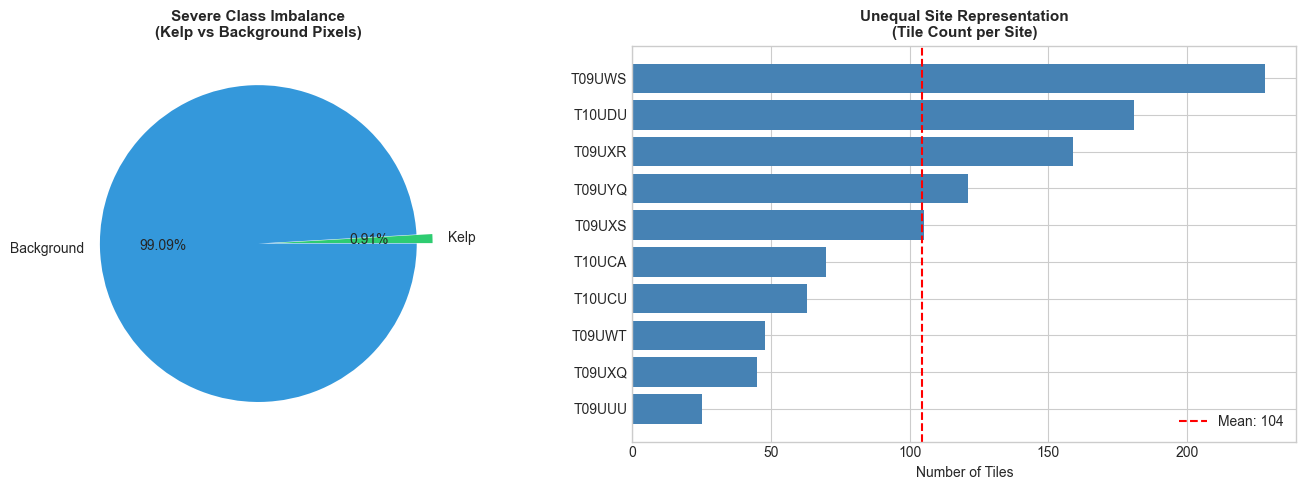

In [17]:
# BC Sentinel-2: WEAKNESSES
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                              WEAKNESSES                                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  W1. SEVERE CLASS IMBALANCE                                                  ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Overall kelp prevalence: ~0.92% (less than 1% of pixels are kelp!)        ║
║  • Range across sites: 0.22% (T10UCA) to 1.68% (T09UWT)                      ║
║  • ~99% of pixels are background (water, land, cloud)                        ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Standard accuracy metrics will be misleading (99% accuracy by           ║
║      predicting all-background)                                              ║
║    - Models will be biased toward predicting "no kelp"                       ║
║    - Requires careful loss function design (focal loss, weighted CE)         ║
║    - IoU/F1 metrics will be more informative than accuracy                   ║
║  • IMPLICATION FOR LA FRAMEWORK: The reward function R(ŷ,y) must use IoU     ║
║    or F1, NOT pixel accuracy. Otherwise, a "predict all zero" heuristic      ║
║    would appear to perform well.                                             ║
║                                                                              ║
║  W2. LIMITED TEMPORAL COVERAGE                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Only 1 image per site (single temporal snapshot)                          ║
║  • Date range: Sept 2020 - Sept 2023 (3 years, but only 10 observations)     ║
║  • No seasonal coverage (all images from July-September)                     ║
║  • No inter-annual comparison possible for same site                         ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Cannot evaluate temporal domain shift (RQ1 objective)                   ║
║    - Kelp phenology varies seasonally (peak biomass in summer/fall)          ║
║    - Cannot detect kelp loss/recovery trends                                 ║
║    - LA framework cannot learn temporal adaptation patterns                  ║
║  • CRITICAL QUESTION: Is this dataset sufficient to evaluate the LA          ║
║    framework's temporal adaptation capabilities? Likely NO.                  ║
║                                                                              ║
║  W3. INCONSISTENT TILE COUNTS ACROSS SITES                                   ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • T09UWS: 228 tiles vs T09UUU: 25 tiles (9x difference!)                    ║
║  • Unbalanced representation of different environments                       ║
║  • Some sites heavily over-represented in training                           ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Models may overfit to high-tile-count sites                             ║
║    - Site-level cross-validation will have unequal folds                     ║
║    - LA framework may learn biased heuristic preferences                     ║
║                                                                              ║
║  W4. UNKNOWN MASK ANNOTATION QUALITY                                         ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Masks are binary (0/1) - but what's the source?                           ║
║  • No information on annotation methodology provided                         ║
║  • Are these expert annotations? Semi-automated? Thresholding?               ║
║  • No inter-annotator agreement metrics                                      ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Ground truth quality directly impacts model evaluation                  ║
║    - If masks are thresholded indices, they may be circular                  ║
║    - Cannot assess annotation uncertainty                                    ║
║  • CRITICAL QUESTION: How were these masks created? This needs documentation.║
║                                                                              ║
║  W5. MISSING DATA FOR T10UDU                                                 ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • T10UDU (Victoria) lacks Bathymetry and Substrate auxiliary layers         ║
║  • Most southerly site - important for geographic coverage                   ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Auxiliary data is key to context-aware adaptation (RQ2)                 ║
║    - Either exclude T10UDU or handle missing data gracefully                 ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Print actual statistics for weaknesses
print("\n>>> WEAKNESS STATISTICS:")
print(f"    • Overall kelp prevalence: {overall_kelp_pct:.3f}%")
print(f"    • Kelp prevalence range: {prevalence_df['kelp_pct'].min():.3f}% - {prevalence_df['kelp_pct'].max():.3f}%")
print(f"    • Tile count range: {scenes_df['n_tiles'].min()} - {scenes_df['n_tiles'].max()}")
print(f"    • Temporal samples per site: 1 (no repeat coverage)")
print(f"    • Seasonal coverage: Summer only ({scenes_df['month'].unique()})")

# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of class distribution
axes[0].pie([overall_kelp_pct, 100-overall_kelp_pct], 
            labels=['Kelp', 'Background'], 
            autopct='%1.2f%%',
            colors=['#2ecc71', '#3498db'],
            explode=(0.1, 0))
axes[0].set_title('Severe Class Imbalance\n(Kelp vs Background Pixels)', fontsize=11, fontweight='bold')

# Tile count distribution
ax2 = axes[1]
site_tiles = scenes_df.set_index('site_code')['n_tiles'].sort_values()
bars = ax2.barh(site_tiles.index, site_tiles.values, color='steelblue')
ax2.set_xlabel('Number of Tiles')
ax2.set_title('Unequal Site Representation\n(Tile Count per Site)', fontsize=11, fontweight='bold')
ax2.axvline(site_tiles.mean(), color='red', linestyle='--', label=f'Mean: {site_tiles.mean():.0f}')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bc_weaknesses_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


╔══════════════════════════════════════════════════════════════════════════════╗
║                             OPPORTUNITIES                                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  O1. GOOGLE EARTH ENGINE EXPANSION                                           ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Can download additional Sentinel-2 imagery for same sites via GEE         ║
║  • Sentinel-2 archive goes back to 2015 (10+ years of data)                  ║
║  • 5-day revisit time = ~70 potential images per site per year               ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Address temporal coverage weakness (W2)                                 ║
║    - Enable seasonal analysis (spring vs summer vs fall kelp extent)         ║
║    - Create multi-tempor

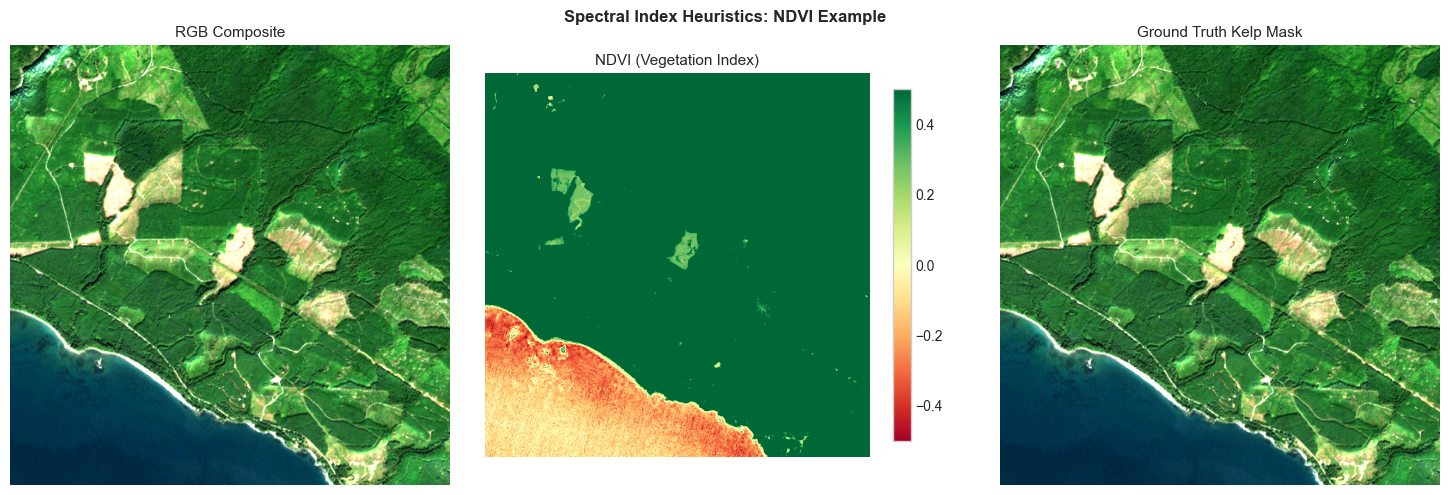

    • NDVI range: [-0.523, 0.939]
    • NDVI mean: 0.673


In [18]:
# BC Sentinel-2: OPPORTUNITIES
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                             OPPORTUNITIES                                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  O1. GOOGLE EARTH ENGINE EXPANSION                                           ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Can download additional Sentinel-2 imagery for same sites via GEE         ║
║  • Sentinel-2 archive goes back to 2015 (10+ years of data)                  ║
║  • 5-day revisit time = ~70 potential images per site per year               ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Address temporal coverage weakness (W2)                                 ║
║    - Enable seasonal analysis (spring vs summer vs fall kelp extent)         ║
║    - Create multi-temporal sequences for time-series modeling                ║
║    - Test LA framework's temporal adaptation capabilities                    ║
║  • ACTION REQUIRED: Phase 0.5 should prioritize GEE data acquisition         ║
║                                                                              ║
║  O2. CROSS-SENSOR TRANSFER LEARNING                                          ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Figshare Landsat dataset provides 421 additional RGB images               ║
║  • Different geographic context (California) = diversity                     ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Pre-train RGB-based heuristics on Figshare, fine-tune on BC             ║
║    - Test cross-sensor generalization (Landsat 30m → Sentinel 10m)           ║
║    - Increase effective training data volume                                 ║
║    - Validate that kelp detection transfers across ecosystems                ║
║                                                                              ║
║  O3. CONTEXT FEATURE ENGINEERING                                             ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Auxiliary layers enable rich context vectors for LA framework             ║
║  • Bathymetry: depth constraints for kelp habitat                            ║
║  • Substrate: rocky = suitable, sandy = unsuitable                           ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Context-aware local adaptation (Component 2) can leverage this          ║
║    - Memory bank can store (depth, substrate, performance) tuples            ║
║    - Enable "if rocky substrate AND shallow depth THEN use heuristic X"      ║
║                                                                              ║
║  O4. SPECTRAL INDEX HEURISTICS                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 10 spectral bands enable multiple detection indices:                      ║
║    - NDVI = (B8 - B4) / (B8 + B4): vegetation vigor                          ║
║    - FAI = B8 - (B4 + (B11 - B4) * factor): floating algae                   ║
║    - NDWI = (B3 - B8) / (B3 + B8): water presence                            ║
║    - Red-edge ratios: B6/B5, B7/B5 for subtle vegetation                     ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Multiple heuristics for the LA heuristic pool                           ║
║    - Each index may work better under different conditions                   ║
║    - LA framework can learn which index to trust when                        ║
║                                                                              ║
║  O5. LEAVE-ONE-SITE-OUT VALIDATION                                           ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 10 distinct geographic sites enable robust cross-validation               ║
║  • Train on 9 sites, test on 1 held-out site                                 ║
║  • Tests true spatial generalization (not just tile-level splits)            ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Directly evaluates RQ2 (generalization across heterogeneous regions)    ║
║    - Each held-out site represents an "unseen environment"                   ║
║    - Can report performance across all 10 leave-one-out folds                ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Demonstrate spectral index calculation potential
print("\n>>> OPPORTUNITY: Spectral Index Calculation Example")
print("    Computing NDVI for sample tile...")

# NDVI calculation
B4 = tile_data[2]  # Red
B8 = tile_data[3]  # NIR
ndvi = np.where((B8 + B4) != 0, (B8 - B4) / (B8 + B4 + 1e-8), 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb)
axes[0].set_title('RGB Composite', fontsize=11)
axes[0].axis('off')

im1 = axes[1].imshow(ndvi, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
axes[1].set_title('NDVI (Vegetation Index)', fontsize=11)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Kelp mask comparison
axes[2].imshow(rgb)
mask_overlay = np.ma.masked_where(mask_data == 0, mask_data)
axes[2].imshow(mask_overlay, cmap='Reds', alpha=0.5)
axes[2].set_title('Ground Truth Kelp Mask', fontsize=11)
axes[2].axis('off')

plt.suptitle('Spectral Index Heuristics: NDVI Example', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bc_spectral_indices.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"    • NDVI range: [{ndvi.min():.3f}, {ndvi.max():.3f}]")
print(f"    • NDVI mean: {ndvi.mean():.3f}")


╔══════════════════════════════════════════════════════════════════════════════╗
║                               THREATS                                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  T1. OVERFITTING TO SUMMER CONDITIONS                                        ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • All images from July-September (peak kelp season)                         ║
║  • Model may fail on spring/winter imagery                                   ║
║  • Kelp canopy appearance varies with season (submerged vs floating)         ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Operational monitoring requires year-round detection                    ║
║    - LA framework will not learn seasonal adaptation patterns                ║
║    - Published results m

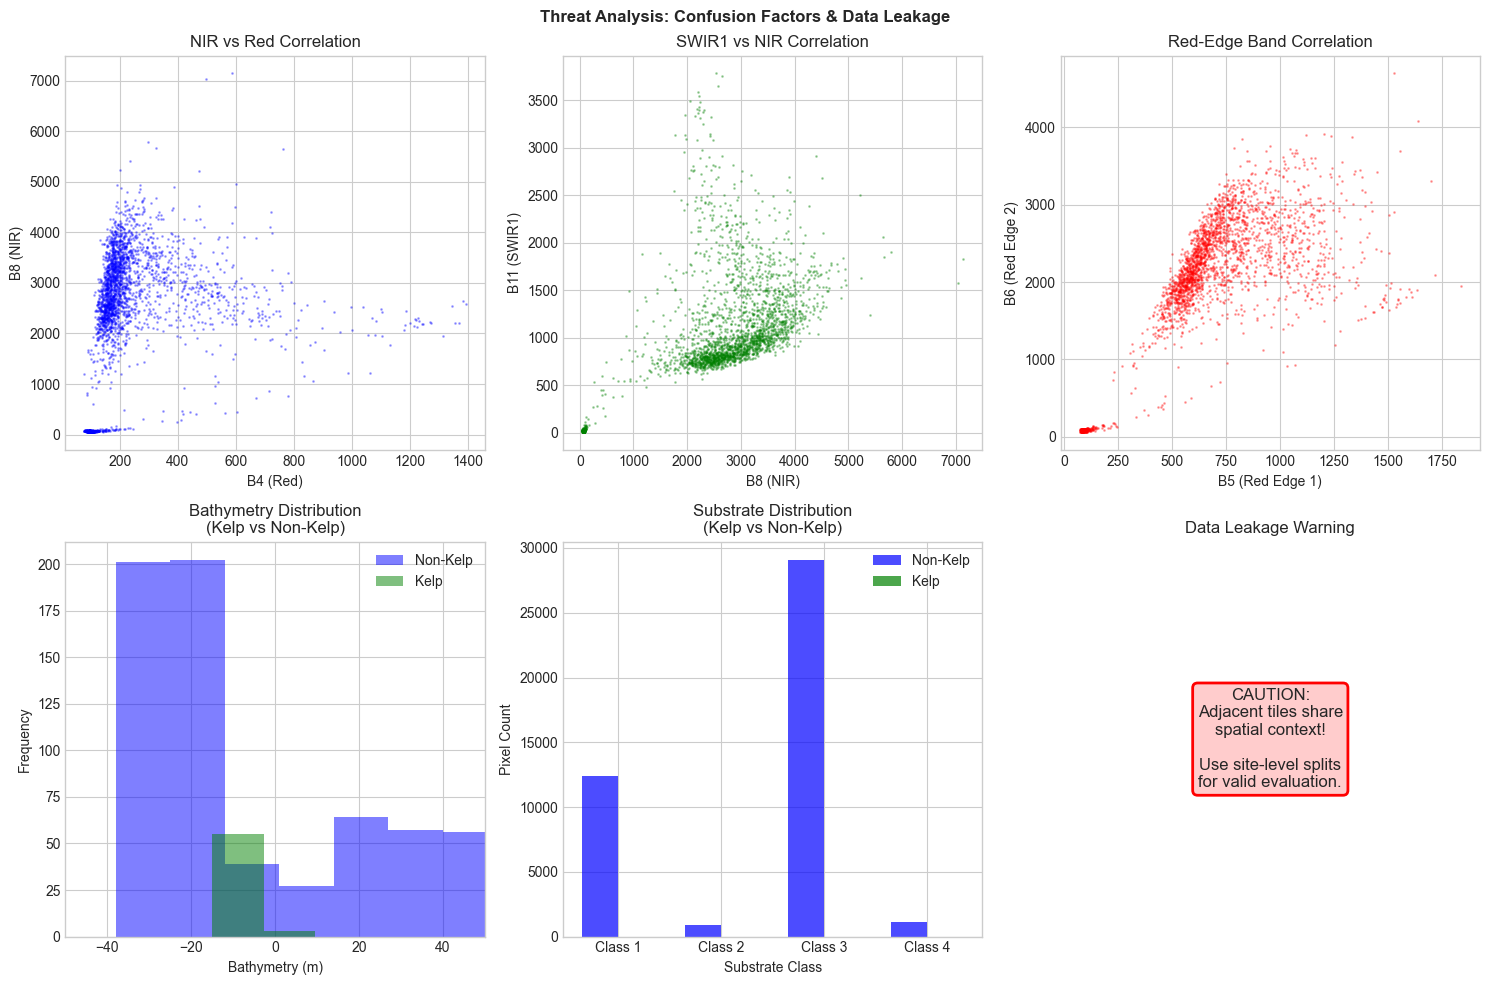

In [19]:
# BC Sentinel-2: THREATS
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                               THREATS                                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  T1. OVERFITTING TO SUMMER CONDITIONS                                        ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • All images from July-September (peak kelp season)                         ║
║  • Model may fail on spring/winter imagery                                   ║
║  • Kelp canopy appearance varies with season (submerged vs floating)         ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Operational monitoring requires year-round detection                    ║
║    - LA framework will not learn seasonal adaptation patterns                ║
║    - Published results may not generalize to operational deployment          ║
║  • MITIGATION: GEE expansion with seasonal coverage (Phase 0.5)              ║
║                                                                              ║
║  T2. GEOGRAPHIC BIAS TOWARD ACCESSIBLE SITES                                 ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Sites may be biased toward areas with existing research programs          ║
║  • Remote areas of BC coast may be under-represented                         ║
║  • Haida Gwaii (T09UUU) has only 25 tiles - lowest coverage                  ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Research findings may not generalize to entire BC coast                 ║
║    - Traditional Ecological Knowledge integration (RQ5) may require          ║
║      additional sites where First Nations communities are active             ║
║                                                                              ║
║  T3. SINGLE-SOURCE GROUND TRUTH                                              ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • All masks appear to come from same annotation pipeline                    ║
║  • No independent validation dataset                                         ║
║  • No field-collected ground truth referenced                                ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Systematic annotation errors will propagate to all evaluations          ║
║    - Cannot distinguish model errors from annotation errors                  ║
║    - Academic reviewers may question validity without field validation       ║
║  • MITIGATION: Seek partnerships with DFO/Parks Canada for field validation  ║
║                                                                              ║
║  T4. SPECTRAL CONFUSION RISKS                                                ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Kelp can be confused with:                                                ║
║    - Eelgrass (similar spectral signature, different depth)                  ║
║    - Sun glint on water (high reflectance artifacts)                         ║
║    - Floating debris (logs common in BC waters)                              ║
║    - Phytoplankton blooms (similar NIR response)                             ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - False positives reduce precision metrics                                ║
║    - LA framework may select heuristics that are fooled by confusers         ║
║    - Context data (bathymetry) should help but is not sufficient alone       ║
║                                                                              ║
║  T5. DATA LEAKAGE IN TILE-BASED SPLITTING                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Adjacent 512×512 tiles share spatial context                              ║
║  • Random train/test splits may include adjacent tiles in both sets          ║
║  • Inflates reported performance due to spatial autocorrelation              ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Published metrics may be overly optimistic                              ║
║    - True generalization performance may be lower                            ║
║  • MITIGATION: Use site-level splits (leave-one-site-out) not tile splits   ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Analyze potential spectral confusion
print("\n>>> THREAT ANALYSIS: Spectral Confusion Potential")
print("    Examining band correlations that could lead to confusion...")

# Check correlation between bands that might cause confusion
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# NIR vs Red (NDVI basis)
axes[0, 0].scatter(tile_data[2].flatten()[::100], tile_data[3].flatten()[::100], 
                   alpha=0.3, s=1, c='blue')
axes[0, 0].set_xlabel('B4 (Red)')
axes[0, 0].set_ylabel('B8 (NIR)')
axes[0, 0].set_title('NIR vs Red Correlation')

# SWIR1 vs NIR (water vs vegetation)
axes[0, 1].scatter(tile_data[3].flatten()[::100], tile_data[8].flatten()[::100], 
                   alpha=0.3, s=1, c='green')
axes[0, 1].set_xlabel('B8 (NIR)')
axes[0, 1].set_ylabel('B11 (SWIR1)')
axes[0, 1].set_title('SWIR1 vs NIR Correlation')

# Red-edge progression
axes[0, 2].scatter(tile_data[4].flatten()[::100], tile_data[5].flatten()[::100], 
                   alpha=0.3, s=1, c='red')
axes[0, 2].set_xlabel('B5 (Red Edge 1)')
axes[0, 2].set_ylabel('B6 (Red Edge 2)')
axes[0, 2].set_title('Red-Edge Band Correlation')

# Bathymetry vs Kelp
bath_sample = tile_data[11]  # Bathymetry
kelp_depths = bath_sample[mask_data == 1] if np.any(mask_data == 1) else np.array([])
non_kelp_depths = bath_sample[mask_data == 0]

axes[1, 0].hist(non_kelp_depths.flatten()[::100], bins=50, alpha=0.5, label='Non-Kelp', color='blue')
if len(kelp_depths) > 0:
    axes[1, 0].hist(kelp_depths.flatten(), bins=50, alpha=0.5, label='Kelp', color='green')
axes[1, 0].set_xlabel('Bathymetry (m)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Bathymetry Distribution\n(Kelp vs Non-Kelp)')
axes[1, 0].legend()
axes[1, 0].set_xlim(-50, 50)

# Substrate vs Kelp
sub_sample = tile_data[10]  # Substrate
kelp_substrate = sub_sample[mask_data == 1] if np.any(mask_data == 1) else np.array([])
non_kelp_substrate = sub_sample[mask_data == 0]

substrate_classes = [1, 2, 3, 4]
kelp_counts = [np.sum(kelp_substrate == c) for c in substrate_classes]
non_kelp_counts = [np.sum(non_kelp_substrate == c) for c in substrate_classes]

x = np.arange(len(substrate_classes))
width = 0.35
axes[1, 1].bar(x - width/2, non_kelp_counts, width, label='Non-Kelp', color='blue', alpha=0.7)
axes[1, 1].bar(x + width/2, kelp_counts, width, label='Kelp', color='green', alpha=0.7)
axes[1, 1].set_xlabel('Substrate Class')
axes[1, 1].set_ylabel('Pixel Count')
axes[1, 1].set_title('Substrate Distribution\n(Kelp vs Non-Kelp)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['Class 1', 'Class 2', 'Class 3', 'Class 4'])
axes[1, 1].legend()

# Tile adjacency threat visualization
axes[1, 2].text(0.5, 0.5, 'CAUTION:\nAdjacent tiles share\nspatial context!\n\nUse site-level splits\nfor valid evaluation.', 
               ha='center', va='center', fontsize=12, 
               bbox=dict(boxstyle='round', facecolor='#ffcccc', edgecolor='red', linewidth=2))
axes[1, 2].axis('off')
axes[1, 2].set_title('Data Leakage Warning')

plt.suptitle('Threat Analysis: Confusion Factors & Data Leakage', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bc_threats_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# BC Sentinel-2: CRITICAL QUESTIONS & GAPS
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    CRITICAL QUESTIONS (Investigator's Notes)                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CQ1. HOW WERE THE GROUND TRUTH MASKS CREATED?                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Were they manually annotated by experts?                                  ║
║  ? Were they generated by threshold-based detection algorithms?              ║
║  ? If threshold-based, there's risk of circularity if we use similar methods ║
║  ? What is the inter-annotator agreement (if multiple annotators)?           ║
║  ➤ ACTION: Document annotation methodology before publication                 ║
║                                                                              ║
║  CQ2. WHY ARE TILE COUNTS SO VARIABLE ACROSS SITES?                          ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Why does T09UWS have 228 tiles but T09UUU only 25?                        ║
║  ? Is this due to cloud cover masking?                                       ║
║  ? Is this due to different coastline extents per scene?                     ║
║  ? Should we up-sample low-count sites or down-sample high-count?            ║
║  ➤ ACTION: Investigate original tiling methodology                           ║
║                                                                              ║
║  CQ3. WHAT ARE THE SUBSTRATE CLASSES?                                        ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Substrate has 4 classes (1-4) but no legend provided                      ║
║  ? Assumed: 1=rock, 2=sand, 3=mud, 4=mixed? Need confirmation                ║
║  ? How was substrate mapped? Multibeam sonar? Seabed classification?         ║
║  ➤ ACTION: Document substrate class definitions                              ║
║                                                                              ║
║  CQ4. WHY IS T10UDU MISSING AUXILIARY DATA?                                  ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Is bathymetry/substrate data unavailable for Victoria region?             ║
║  ? Can we source this from CHS (Canadian Hydrographic Service)?              ║
║  ? Should T10UDU be excluded from context-aware experiments?                 ║
║  ➤ ACTION: Either source missing data or document exclusion rationale        ║
║                                                                              ║
║  CQ5. ARE MASKS ALIGNED TEMPORALLY WITH IMAGERY?                             ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Were masks created from the same image acquisition?                       ║
║  ? Kelp canopy visibility varies with tide, time of day, wave action         ║
║  ? Submerged kelp vs. floating canopy detection differences?                 ║
║  ➤ ACTION: Verify temporal alignment of masks and imagery                    ║
║                                                                              ║
║  CQ6. WHAT IS THE CLOUD COVER THRESHOLD USED?                                ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Were cloudy scenes excluded? If so, at what threshold?                    ║
║  ? Does this bias toward clear-sky conditions only?                          ║
║  ? Can LA framework adapt to partially cloudy scenes?                        ║
║  ➤ ACTION: Document scene selection criteria                                 ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                          IDENTIFIED GAPS                                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  GAP 1: No multi-temporal coverage for same site                             ║
║         → Cannot test temporal adaptation (RQ1 partially unaddressable)      ║
║                                                                              ║
║  GAP 2: No seasonal variation in imagery                                     ║
║         → Summer-biased dataset limits operational applicability             ║
║                                                                              ║
║  GAP 3: No environmental condition metadata                                  ║
║         → Missing: tide height, wind speed, sun glint, water turbidity       ║
║         → These are key context features for Component 2                     ║
║                                                                              ║
║  GAP 4: No annotation uncertainty quantification                             ║
║         → Cannot model label noise in LA reward function                     ║
║                                                                              ║
║  GAP 5: No independent validation dataset                                    ║
║         → Single-source ground truth limits external validity                ║
║                                                                              ║
║  GAP 6: Missing TEK integration pathway                                      ║
║         → No First Nations community data sources identified                 ║
║         → RQ5 requires additional partnership development                    ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Quantify gaps
print("\n>>> GAP IMPACT ASSESSMENT:")
print(f"    • Temporal samples per site: 1 (need ≥10 for adaptation testing)")
print(f"    • Seasonal months covered: {sorted(scenes_df['month'].unique())} (need all 12)")
print(f"    • Sites with complete auxiliary data: 9/10 (T10UDU missing)")
print(f"    • Environmental metadata fields: 0 (need: tide, wind, SST, turbidity)")
print(f"    • Independent validation sets: 0 (need ≥1 for external validity)")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    CRITICAL QUESTIONS (Investigator's Notes)                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CQ1. HOW WERE THE GROUND TRUTH MASKS CREATED?                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Were they manually annotated by experts?                                  ║
║  ? Were they generated by threshold-based detection algorithms?              ║
║  ? If threshold-based, there's risk of circularity if we use similar methods ║
║  ? What is the inter-annotator agreement (if multiple annotators)?           ║
║  ➤ ACTION: Document annotation methodology before publication                 ║
║                                                                              ║
║  CQ2. WHY ARE TILE COUN

---
## 5. Critical Analysis: Figshare Landsat Dataset

### SWOT Analysis & Investigative Assessment

In [21]:
# =============================================================================
# FIGSHARE LANDSAT DATASET: SWOT ANALYSIS
# =============================================================================

# Load mask statistics
masks_dir = FIGSHARE_DATA / 'train' / 'masks'
mask_stats = []
if masks_dir.exists():
    for mask_path in masks_dir.glob('*.png'):
        mask = np.array(Image.open(mask_path))
        mask_stats.append({
            'filename': mask_path.stem,
            'kelp_pct': np.sum(mask > 0) / mask.size * 100,
            'has_kelp': np.any(mask > 0)
        })
mask_stats_df = pd.DataFrame(mask_stats)

print("="*80)
print("FIGSHARE LANDSAT: DETAILED SWOT ANALYSIS")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                              STRENGTHS                                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  S1. PRE-DEFINED TRAIN/VAL/TEST SPLITS                                       ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Split: train=317, val=30, test=74 images                                  ║
║  • Enables standardized benchmarking against other methods                   ║
║  • Reproducible evaluation without split randomness                          ║
║  • WHY THIS MATTERS: Can compare LA framework directly to published baselines║
║    using same evaluation protocol.                                           ║
║                                                                              ║
║  S2. POLYGON ANNOTATIONS (INSTANCE-LEVEL)                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • VIA JSON format with polygon regions for each kelp patch                  ║
║  • 3345 total polygon annotations across 421 images                          ║
║  • Multiple kelp beds per image (average ~8 polygons/image)                  ║
║  • WHY THIS MATTERS: Instance-level annotations enable analysis of kelp bed  ║
║    size distribution, fragmentation patterns, and potential instance         ║
║    segmentation experiments beyond binary classification.                    ║
║                                                                              ║
║  S3. DUAL LANDSAT SENSOR COVERAGE                                            ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Landsat 5 (TM): 165 images (1984-2012 era)                                ║
║  • Landsat 8 (OLI): 152 images (2013-present)                                ║
║  • Tests cross-sensor consistency within same dataset                        ║
║  • WHY THIS MATTERS: If models generalize across L5/L8, may also generalize  ║
║    to Sentinel-2. Natural experiment for sensor adaptation.                  ║
║                                                                              ║
║  S4. LARGER SAMPLE SIZE FOR RGB METHODS                                      ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 421 images > BC's 1045 tiles in terms of scene diversity                  ║
║  • Each image = independent acquisition (unlike adjacent BC tiles)           ║
║  • More geographic and temporal diversity in single dataset                  ║
║  • WHY THIS MATTERS: Better statistical power for training RGB-only heuristics║
║                                                                              ║
║  S5. CONSISTENT IMAGE DIMENSIONS                                             ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • All images 1024×1024 pixels (uniform size)                                ║
║  • No need for resizing or padding                                           ║
║  • Simplifies data loading pipeline                                          ║
║  • WHY THIS MATTERS: Reduces preprocessing complexity, eliminates edge cases ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Calculate actual statistics
total_annotations = split_df['n_annotations'].sum()
avg_annotations = total_annotations / split_df['n_images'].sum()
print(f"\n>>> STRENGTH STATISTICS:")
print(f"    • Total images: {split_df['n_images'].sum()}")
print(f"    • Total polygon annotations: {total_annotations}")
print(f"    • Average annotations per image: {avg_annotations:.1f}")
print(f"    • Landsat 5 vs 8 split: {landsat_versions['Landsat 5']} / {landsat_versions['Landsat 8']}")

FIGSHARE LANDSAT: DETAILED SWOT ANALYSIS

╔══════════════════════════════════════════════════════════════════════════════╗
║                              STRENGTHS                                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  S1. PRE-DEFINED TRAIN/VAL/TEST SPLITS                                       ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Split: train=317, val=30, test=74 images                                  ║
║  • Enables standardized benchmarking against other methods                   ║
║  • Reproducible evaluation without split randomness                          ║
║  • WHY THIS MATTERS: Can compare LA framework directly to published baselines║
║    using same evaluation protocol.                                           ║
║                                                                 

In [22]:
# FIGSHARE LANDSAT: WEAKNESSES
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                              WEAKNESSES                                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  W1. RGB-ONLY IMAGERY                                                        ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Only 3 bands (RGB) available - no NIR, red-edge, or SWIR                  ║
║  • Cannot compute NDVI, FAI, or other vegetation indices                     ║
║  • Spectral information is heavily compressed                                ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Limits heuristic pool to RGB-based methods only                         ║
║    - Cannot exploit kelp's distinctive NIR signature                         ║
║    - Harder to distinguish kelp from green algae, turbid water               ║
║  • IMPLICATION: Figshare best used for RGB-only heuristic pre-training,      ║
║    not for full multi-spectral LA framework development.                     ║
║                                                                              ║
║  W2. COARSER SPATIAL RESOLUTION                                              ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Landsat: 30m resolution vs Sentinel-2: 10m resolution                     ║
║  • 3× worse spatial detail per pixel                                         ║
║  • 1024×1024 @ 30m = 30.7 km × 30.7 km (much larger footprint than BC tiles) ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Small kelp patches may be sub-pixel (missed entirely)                   ║
║    - Resolution mismatch complicates cross-sensor transfer                   ║
║    - Direct pixel-level comparison with BC tiles is invalid                  ║
║                                                                              ║
║  W3. DIFFERENT GEOGRAPHIC CONTEXT (CALIFORNIA)                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • California kelp (Macrocystis pyrifera - giant kelp)                       ║
║  • BC kelp (Nereocystis luetkeana - bull kelp, also Macrocystis)             ║
║  • Different oceanographic conditions (California Current vs Alaska Current) ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Species differences may affect spectral signatures                      ║
║    - Environmental conditions (SST, nutrients) differ systematically         ║
║    - Transfer learning may have domain gap                                   ║
║  • HOWEVER: This is also an opportunity to test cross-ecosystem generalization║
║                                                                              ║
║  W4. SMALL VALIDATION SET                                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Only 30 validation images (7% of dataset)                                 ║
║  • High variance in validation metrics                                       ║
║  • May not represent full distribution of conditions                         ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Model selection may be unreliable                                       ║
║    - Early stopping decisions may be noisy                                   ║
║    - Hyperparameter tuning will have high variance                           ║
║                                                                              ║
║  W5. NO AUXILIARY DATA                                                       ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • No bathymetry, substrate, or environmental context                        ║
║  • Cannot test context-aware adaptation (Component 2) with this dataset      ║
║  • Location metadata not provided (lat/lon, path/row)                        ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - LA framework's context-aware component cannot be fully evaluated        ║
║    - Missing opportunity to learn environment-heuristic mappings             ║
║                                                                              ║
║  W6. LOSSY JPEG COMPRESSION                                                  ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Images stored as JPEG (lossy) not TIFF (lossless)                         ║
║  • Compression artifacts may affect fine-scale detection                     ║
║  • Original radiometric values lost                                          ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Cannot perform radiometric calibration                                  ║
║    - Thresholding methods may hit compression artifacts                      ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Quantify weaknesses
print("\n>>> WEAKNESS STATISTICS:")
print(f"    • Bands available: 3 RGB (vs 12 in BC)")
print(f"    • Spatial resolution: 30m (vs 10m in BC)")
print(f"    • Validation set size: {split_df[split_df['split']=='val']['n_images'].values[0]} images ({split_df[split_df['split']=='val']['n_images'].values[0] / split_df['n_images'].sum() * 100:.1f}%)")
print(f"    • Auxiliary data: None")
print(f"    • Format: JPEG (lossy compression)")


╔══════════════════════════════════════════════════════════════════════════════╗
║                              WEAKNESSES                                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  W1. RGB-ONLY IMAGERY                                                        ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Only 3 bands (RGB) available - no NIR, red-edge, or SWIR                  ║
║  • Cannot compute NDVI, FAI, or other vegetation indices                     ║
║  • Spectral information is heavily compressed                                ║
║  • WHY THIS IS PROBLEMATIC:                                                  ║
║    - Limits heuristic pool to RGB-based methods only                         ║
║    - Cannot exploit kelp's distinctive NIR signature                         ║
║    - Harder to distingui


╔══════════════════════════════════════════════════════════════════════════════╗
║                             OPPORTUNITIES                                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  O1. RGB HEURISTIC PRE-TRAINING                                              ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Train RGB-only heuristics (U-Net, DeepLab) on Figshare                    ║
║  • Transfer learned features to BC dataset                                   ║
║  • Increase effective training data for RGB branch                           ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - 421 diverse scenes provide robust RGB feature learning                  ║
║    - Pretrained RGB encoder can be frozen, only fine-tune on BC              ║
║    - Addresses BC's limi

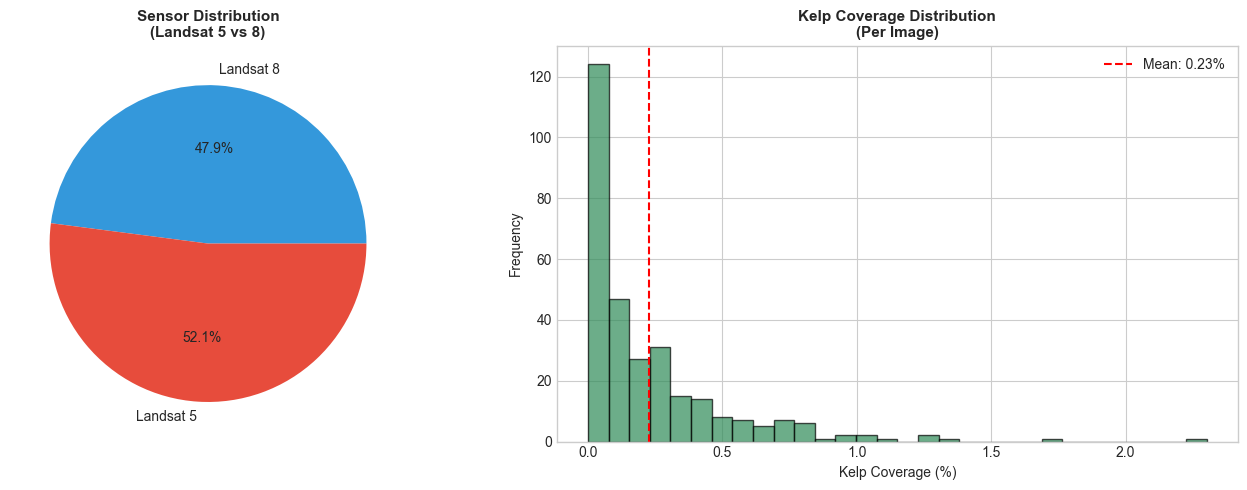

In [23]:
# FIGSHARE LANDSAT: OPPORTUNITIES & THREATS
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                             OPPORTUNITIES                                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  O1. RGB HEURISTIC PRE-TRAINING                                              ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Train RGB-only heuristics (U-Net, DeepLab) on Figshare                    ║
║  • Transfer learned features to BC dataset                                   ║
║  • Increase effective training data for RGB branch                           ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - 421 diverse scenes provide robust RGB feature learning                  ║
║    - Pretrained RGB encoder can be frozen, only fine-tune on BC              ║
║    - Addresses BC's limited scene diversity                                  ║
║                                                                              ║
║  O2. CROSS-ECOSYSTEM GENERALIZATION STUDY                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • California → BC transfer tests geographic generalization                  ║
║  • Different kelp species (Macrocystis vs Nereocystis) tests species transfer║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - If methods generalize California→BC, strong evidence for robustness     ║
║    - Directly tests RQ2 (heterogeneous region adaptation)                    ║
║    - Publication angle: "Cross-ecosystem kelp detection"                     ║
║                                                                              ║
║  O3. INSTANCE SEGMENTATION ANALYSIS                                          ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Polygon annotations enable kelp bed counting                              ║
║  • Can analyze: bed size distribution, fragmentation, clustering             ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Go beyond binary segmentation to instance metrics                       ║
║    - Ecological relevance: bed connectivity affects ecosystem function       ║
║                                                                              ║
║  O4. HISTORICAL TREND ANALYSIS                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Landsat 5 images span 1984-2012                                           ║
║  • Landsat 8 images span 2013-present                                        ║
║  • Combined: ~40 years of kelp history (if temporal metadata available)      ║
║  • WHY THIS IS AN OPPORTUNITY:                                               ║
║    - Detect long-term kelp decline/recovery patterns                         ║
║    - Climate change impact analysis                                          ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                               THREATS                                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  T1. DOMAIN SHIFT TO BC MAY BE SEVERE                                        ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • California and BC have different:                                         ║
║    - Water color (turbidity, chlorophyll, CDOM)                              ║
║    - Kelp species composition                                                ║
║    - Background substrates                                                   ║
║    - Cloud/atmospheric conditions                                            ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Transfer learning may fail without domain adaptation                    ║
║    - Performance on Figshare does not guarantee BC performance               ║
║                                                                              ║
║  T2. SENSOR GENERATION DIFFERENCES                                           ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Landsat 5 TM vs Landsat 8 OLI have different spectral response functions  ║
║  • Band wavelengths are slightly different                                   ║
║  • Radiometric calibration coefficients differ                               ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Models trained on one sensor may not transfer to other                  ║
║    - Should stratify by sensor in experiments                                ║
║                                                                              ║
║  T3. UNKNOWN ANNOTATION CONSISTENCY                                          ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Multiple annotators? Single annotator?                                    ║
║  • Annotation guidelines not documented                                      ║
║  • Polygon boundary precision unknown                                        ║
║  • WHY THIS IS A THREAT:                                                     ║
║    - Annotation noise adds to model uncertainty                              ║
║    - Edge cases may be inconsistently labeled                                ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Visualize sensor distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Landsat version pie chart
ax0 = axes[0]
ax0.pie(list(landsat_versions.values()), labels=list(landsat_versions.keys()),
        autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
ax0.set_title('Sensor Distribution\n(Landsat 5 vs 8)', fontsize=11, fontweight='bold')

# Mask kelp coverage distribution
ax1 = axes[1]
if len(mask_stats_df) > 0:
    ax1.hist(mask_stats_df['kelp_pct'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
    ax1.set_xlabel('Kelp Coverage (%)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Kelp Coverage Distribution\n(Per Image)', fontsize=11, fontweight='bold')
    ax1.axvline(mask_stats_df['kelp_pct'].mean(), color='red', linestyle='--', 
                label=f'Mean: {mask_stats_df["kelp_pct"].mean():.2f}%')
    ax1.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figshare_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


╔══════════════════════════════════════════════════════════════════════════════╗
║                    CRITICAL QUESTIONS (Investigator's Notes)                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CQ1. WHAT IS THE TEMPORAL DISTRIBUTION OF IMAGES?                           ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Filenames have dates (e.g., LC08_037041_20130906) - can extract           ║
║  ? What years are covered? What seasons?                                     ║
║  ? Is temporal distribution balanced across train/val/test?                  ║
║  ➤ ACTION: Parse filenames to extract and visualize temporal distribution    ║
║                                                                              ║
║  CQ2. WHAT IS THE GEOGRAPHIC DISTRIBUTION?                                   ║
║  ───────────────────────

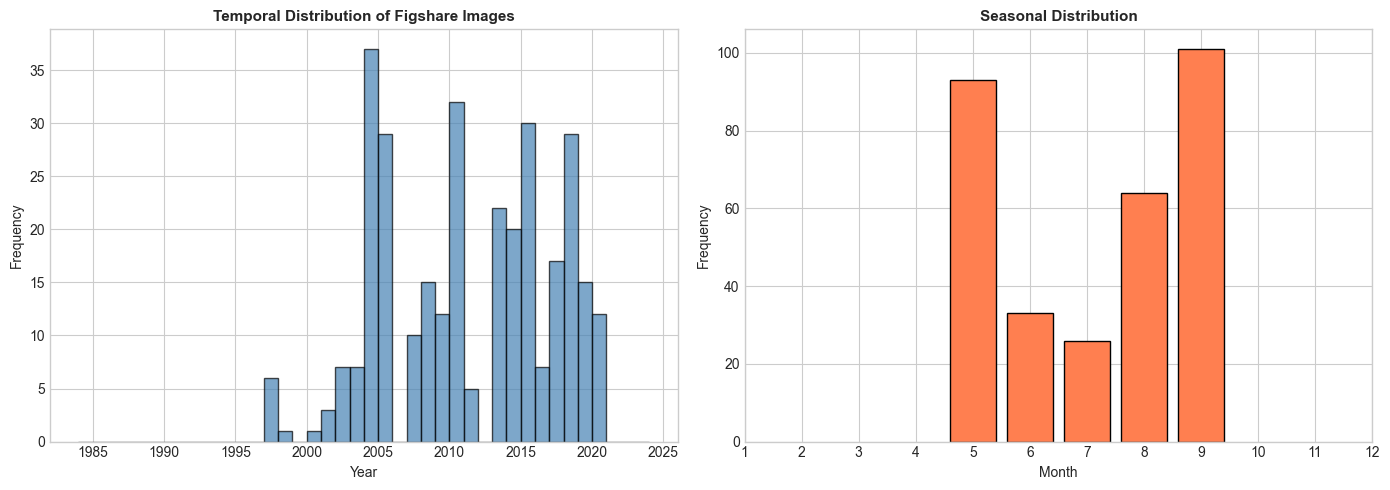

In [24]:
# FIGSHARE LANDSAT: CRITICAL QUESTIONS & GAPS
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    CRITICAL QUESTIONS (Investigator's Notes)                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CQ1. WHAT IS THE TEMPORAL DISTRIBUTION OF IMAGES?                           ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Filenames have dates (e.g., LC08_037041_20130906) - can extract           ║
║  ? What years are covered? What seasons?                                     ║
║  ? Is temporal distribution balanced across train/val/test?                  ║
║  ➤ ACTION: Parse filenames to extract and visualize temporal distribution    ║
║                                                                              ║
║  CQ2. WHAT IS THE GEOGRAPHIC DISTRIBUTION?                                   ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Path/row information in filenames (037041 = path 37, row 41?)             ║
║  ? How many distinct locations are represented?                              ║
║  ? Are train/val/test splits spatially stratified?                           ║
║  ➤ ACTION: Parse filenames to extract and map geographic distribution        ║
║                                                                              ║
║  CQ3. WHY 95% KELP PREVALENCE vs BC's 0.92%?                                 ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Figshare shows 95.3% of images have kelp (much higher than BC)            ║
║  ? Is this selection bias (only images with kelp were annotated)?            ║
║  ? Does this mean Figshare is not representative of real-world distribution? ║
║  ➤ WARNING: This could lead to models biased toward over-detecting kelp      ║
║                                                                              ║
║  CQ4. HOW WERE TRAIN/VAL/TEST SPLITS CREATED?                                ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Random split? Temporal split? Geographic split?                           ║
║  ? If random, adjacent scenes may be in different splits (data leakage)      ║
║  ➤ ACTION: Verify split methodology from original publication                ║
║                                                                              ║
║  CQ5. WHAT ARE THE ORIGINAL LANDSAT PROCESSING LEVELS?                       ║
║  ────────────────────────────────────────────────────────────────────────────║
║  ? Level 1 (TOA) vs Level 2 (Surface Reflectance)?                           ║
║  ? Were atmospheric corrections applied?                                     ║
║  ? Cloud masking methodology?                                                ║
║  ➤ ACTION: Document preprocessing from original source                       ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                          IDENTIFIED GAPS                                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  GAP 1: No multi-spectral bands available                                    ║
║         → Cannot test spectral index heuristics on this dataset              ║
║                                                                              ║
║  GAP 2: No auxiliary environmental data                                      ║
║         → Cannot test context-aware adaptation (Component 2)                 ║
║                                                                              ║
║  GAP 3: Unknown temporal and spatial metadata                                ║
║         → Cannot verify absence of data leakage                              ║
║                                                                              ║
║  GAP 4: Resolution mismatch with BC dataset                                  ║
║         → 30m vs 10m complicates direct transfer                             ║
║                                                                              ║
║  GAP 5: Selection bias toward kelp-present images                            ║
║         → 95% kelp prevalence unrealistic for operational deployment         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Parse temporal information from filenames
train_dir = FIGSHARE_DATA / 'train'
valid_images = [f for f in train_dir.glob('*.jpg') if not f.name.startswith('._')]

dates = []
path_rows = []
for img_path in valid_images:
    parts = img_path.stem.split('_')
    if len(parts) >= 3:
        path_rows.append(parts[1])  # e.g., 037041
        date_str = parts[2]  # e.g., 20130906
        if len(date_str) == 8:
            dates.append({
                'year': int(date_str[:4]),
                'month': int(date_str[4:6]),
                'path_row': parts[1]
            })

dates_df = pd.DataFrame(dates)

if len(dates_df) > 0:
    print("\n>>> EXTRACTED TEMPORAL/SPATIAL METADATA:")
    print(f"    • Years covered: {sorted(dates_df['year'].unique())}")
    print(f"    • Unique path/rows: {len(dates_df['path_row'].unique())}")
    print(f"    • Date range: {dates_df['year'].min()} - {dates_df['year'].max()}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(dates_df['year'], bins=range(1984, 2025), edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Temporal Distribution of Figshare Images', fontsize=11, fontweight='bold')
    
    month_counts = dates_df['month'].value_counts().sort_index()
    axes[1].bar(month_counts.index, month_counts.values, color='coral', edgecolor='black')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Frequency')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_title('Seasonal Distribution', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figshare_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Cross-Dataset Comparative Analysis

### Synthesis: BC Sentinel-2 vs Figshare Landsat

In [25]:
# =============================================================================
# CROSS-DATASET COMPARATIVE ANALYSIS
# =============================================================================

print("="*80)
print("CROSS-DATASET SYNTHESIS: BC SENTINEL-2 vs FIGSHARE LANDSAT")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    COMPARATIVE ANALYSIS TABLE                                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  DIMENSION         │ BC SENTINEL-2           │ FIGSHARE LANDSAT             ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  Geographic Region │ British Columbia, Canada│ California, USA              ║
║  Kelp Species      │ Bull kelp (Nereocystis) │ Giant kelp (Macrocystis)     ║
║  Sensor            │ Sentinel-2 MSI          │ Landsat 5 TM / Landsat 8 OLI ║
║  Spatial Resolution│ 10m (RGB/NIR)           │ 30m                          ║
║  Spectral Bands    │ 12 (incl. auxiliary)    │ 3 (RGB only)                 ║
║  Image Size        │ 512×512 (tiles)         │ 1024×1024                    ║
║  Ground Coverage   │ 5.12×5.12 km/tile       │ 30.7×30.7 km/image           ║
║  Total Samples     │ 1045 tiles              │ 421 images                   ║
║  Scene Diversity   │ 10 scenes (1 per site)  │ 421 unique acquisitions      ║
║  Temporal Range    │ 2020-2023 (3 years)     │ 1984-2020+ (~36 years)       ║
║  Seasonal Coverage │ July-September only     │ Multiple seasons (TBD)       ║
║  Kelp Prevalence   │ 0.92% (pixel-level)     │ 95.3% (image-level)          ║
║  Auxiliary Data    │ Bathymetry, Substrate   │ None                         ║
║  Annotation Format │ Binary raster masks     │ VIA polygon JSON             ║
║  Pre-split         │ No                      │ Yes (train/val/test)         ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Dimension': ['Region', 'Sensor', 'Resolution', 'Bands', 'Samples', 'Scene Diversity', 
                  'Kelp Prevalence', 'Auxiliary Data', 'Temporal Range'],
    'BC Sentinel-2': ['BC, Canada', 'Sentinel-2', '10m', '12', '1045 tiles', '10 scenes',
                      '0.92%', 'Yes', '3 years'],
    'Figshare Landsat': ['California, USA', 'Landsat 5/8', '30m', '3 (RGB)', '421 images', 
                         '421 scenes', '95.3%', 'No', '~36 years']
})

print("\n>>> KEY COMPARATIVE INSIGHTS:")
print("""
    1. COMPLEMENTARY STRENGTHS
       • BC: Multi-spectral richness (12 bands) enables spectral index heuristics
       • Figshare: Scene diversity (421) enables robust RGB feature learning
       
    2. OPPOSING WEAKNESSES
       • BC lacks temporal diversity (10 scenes from 1 time point each)
       • Figshare lacks spectral information (RGB only)
       → Combined use addresses both weaknesses
       
    3. CLASS IMBALANCE ASYMMETRY
       • BC: 0.92% kelp (highly imbalanced toward background)
       • Figshare: 95.3% kelp presence (highly imbalanced toward kelp)
       → Training on both could balance model biases
       
    4. RESOLUTION MISMATCH (Critical Challenge)
       • 3× resolution difference (10m vs 30m)
       • Cannot directly transfer pixel-level models
       → Need resolution-agnostic features or resampling strategy
       
    5. DOMAIN GAP (Geographic/Ecological)
       • Different kelp species, oceanography, water properties
       • Transfer learning will face domain shift
       → LA framework should adapt to this shift (RQ2 test)
""")

CROSS-DATASET SYNTHESIS: BC SENTINEL-2 vs FIGSHARE LANDSAT

╔══════════════════════════════════════════════════════════════════════════════╗
║                    COMPARATIVE ANALYSIS TABLE                                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  DIMENSION         │ BC SENTINEL-2           │ FIGSHARE LANDSAT             ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  Geographic Region │ British Columbia, Canada│ California, USA              ║
║  Kelp Species      │ Bull kelp (Nereocystis) │ Giant kelp (Macrocystis)     ║
║  Sensor            │ Sentinel-2 MSI          │ Landsat 5 TM / Landsat 8 OLI ║
║  Spatial Resolution│ 10m (RGB/NIR)           │ 30m                          ║
║  Spectral Bands    │ 12 (incl. auxiliary)    │ 3 (RGB only)                 ║
║  Image Size        │ 512×512 (tiles)         │ 1024×


╔══════════════════════════════════════════════════════════════════════════════╗
║                    DATASET INTEGRATION STRATEGIES                             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  STRATEGY 1: SEQUENTIAL TRANSFER LEARNING                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Step 1: Pre-train RGB-only U-Net on Figshare (421 diverse scenes)           ║
║  Step 2: Fine-tune on BC RGB bands (B4, B3, B2)                              ║
║  Step 3: Extend to 12-band by adding untrained spectral branches             ║
║                                                                              ║
║  WHY: Leverages Figshare's scene diversity for robust RGB features,          ║
║       then specializes to BC's multi-spectral domain.                        ║
║                         

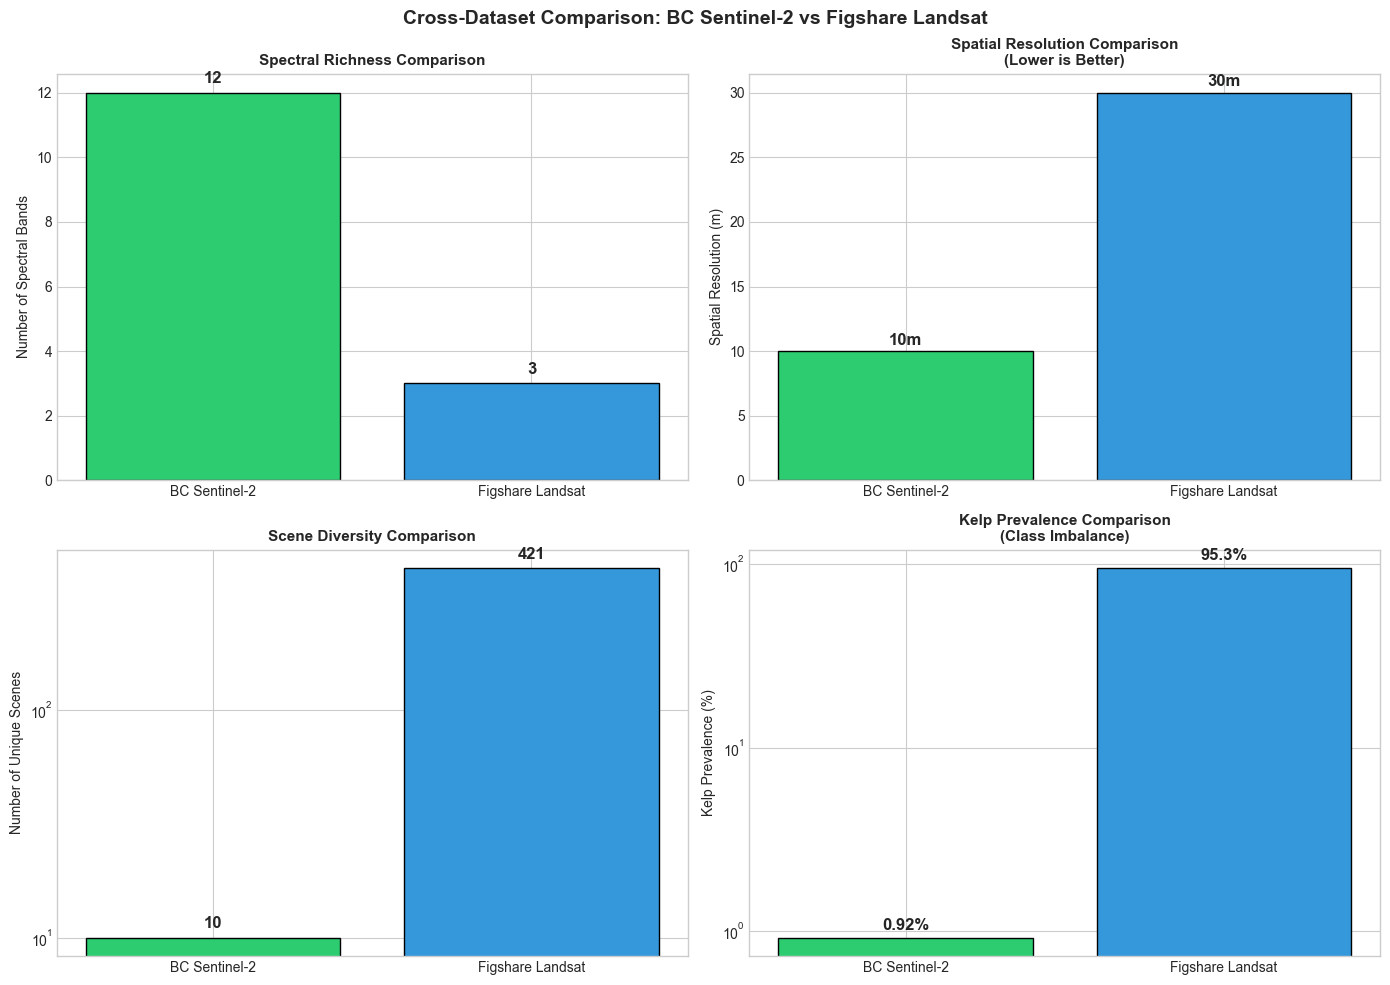

In [26]:
# CROSS-DATASET: INTEGRATION STRATEGIES
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    DATASET INTEGRATION STRATEGIES                             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  STRATEGY 1: SEQUENTIAL TRANSFER LEARNING                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Step 1: Pre-train RGB-only U-Net on Figshare (421 diverse scenes)           ║
║  Step 2: Fine-tune on BC RGB bands (B4, B3, B2)                              ║
║  Step 3: Extend to 12-band by adding untrained spectral branches             ║
║                                                                              ║
║  WHY: Leverages Figshare's scene diversity for robust RGB features,          ║
║       then specializes to BC's multi-spectral domain.                        ║
║                                                                              ║
║  STRATEGY 2: MULTI-TASK HEURISTIC POOL                                       ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • RGB-only heuristics: Train on both datasets (resolution-adjusted)         ║
║  • Spectral heuristics: Train on BC only (NDVI, FAI, etc.)                   ║
║  • Context-aware heuristics: Train on BC only (uses auxiliary data)          ║
║  • LA framework selects from pool based on data availability                 ║
║                                                                              ║
║  WHY: Enables graceful degradation when spectral/auxiliary data unavailable. ║
║                                                                              ║
║  STRATEGY 3: DOMAIN ADAPTATION EXPERIMENT                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Train on: Figshare California data                                          ║
║  Test on: BC data (zero-shot transfer)                                       ║
║  Measure: Domain gap severity                                                ║
║  Then: Apply LA adaptation to close the gap                                  ║
║                                                                              ║
║  WHY: Directly tests RQ2 - can LA framework adapt to unseen environments?    ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                    RECOMMENDED EXPERIMENTAL DESIGN                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EXPERIMENT 1: Within-Dataset Evaluation                                     ║
║  • BC: Leave-one-site-out cross-validation (10 folds)                        ║
║  • Figshare: Standard train/val/test split                                   ║
║  • Report: IoU, F1, Precision, Recall per-fold and averaged                  ║
║                                                                              ║
║  EXPERIMENT 2: Cross-Dataset Transfer                                        ║
║  • Train: Figshare (all), Test: BC (all sites)                               ║
║  • Train: BC (9 sites), Test: Figshare (test set)                            ║
║  • Report: Transfer gap (performance drop vs within-dataset)                 ║
║                                                                              ║
║  EXPERIMENT 3: LA Adaptation Benefit                                         ║
║  • Baseline: Fixed heuristic selection                                       ║
║  • Treatment: LA adaptive selection                                          ║
║  • Report: Performance improvement from adaptation                           ║
║                                                                              ║
║  EXPERIMENT 4: Sparse Label Simulation                                       ║
║  • Simulate delayed label arrival (Component 3)                              ║
║  • Measure: Learning curve with 1%, 5%, 10%, 25%, 50% label availability    ║
║  • Report: Sample efficiency of LA vs retrained baselines                    ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Visual comparison of dataset characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Spectral richness comparison
ax1 = axes[0, 0]
datasets = ['BC Sentinel-2', 'Figshare Landsat']
bands = [12, 3]
colors = ['#2ecc71', '#3498db']
bars = ax1.bar(datasets, bands, color=colors, edgecolor='black')
ax1.set_ylabel('Number of Spectral Bands')
ax1.set_title('Spectral Richness Comparison', fontsize=11, fontweight='bold')
for bar, val in zip(bars, bands):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), 
             ha='center', fontsize=12, fontweight='bold')

# 2. Spatial resolution comparison
ax2 = axes[0, 1]
resolutions = [10, 30]
bars = ax2.bar(datasets, resolutions, color=colors, edgecolor='black')
ax2.set_ylabel('Spatial Resolution (m)')
ax2.set_title('Spatial Resolution Comparison\n(Lower is Better)', fontsize=11, fontweight='bold')
for bar, val in zip(bars, resolutions):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val}m', 
             ha='center', fontsize=12, fontweight='bold')

# 3. Scene diversity comparison
ax3 = axes[1, 0]
scenes = [10, 421]
bars = ax3.bar(datasets, scenes, color=colors, edgecolor='black')
ax3.set_ylabel('Number of Unique Scenes')
ax3.set_title('Scene Diversity Comparison', fontsize=11, fontweight='bold')
ax3.set_yscale('log')
for bar, val in zip(bars, scenes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, str(val), 
             ha='center', fontsize=12, fontweight='bold')

# 4. Kelp prevalence comparison (log scale to show difference)
ax4 = axes[1, 1]
prevalence = [0.92, 95.3]
bars = ax4.bar(datasets, prevalence, color=colors, edgecolor='black')
ax4.set_ylabel('Kelp Prevalence (%)')
ax4.set_title('Kelp Prevalence Comparison\n(Class Imbalance)', fontsize=11, fontweight='bold')
ax4.set_yscale('log')
for bar, val in zip(bars, prevalence):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, f'{val}%', 
             ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Cross-Dataset Comparison: BC Sentinel-2 vs Figshare Landsat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Research Implications & Strategic Recommendations

### Mapping EDA Findings to Research Questions

In [27]:
# =============================================================================
# RESEARCH IMPLICATIONS: EDA FINDINGS → RESEARCH QUESTIONS
# =============================================================================

print("="*80)
print("RESEARCH IMPLICATIONS: HOW EDA FINDINGS INFORM THESIS OBJECTIVES")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  RQ1: How can we adapt kelp segmentation to diverse environmental            ║
║       conditions without extensive labeled data per region?                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EDA FINDINGS RELEVANT TO RQ1:                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • BC dataset has 10 distinct sites = 10 "environmental conditions"          ║
║  • Kelp prevalence varies 8× across sites (0.22% to 1.68%)                   ║
║  • Site-specific spectral signatures likely differ                           ║
║  • Limited temporal coverage means we can't test temporal adaptation         ║
║                                                                              ║
║  IMPLICATIONS:                                                               ║
║  ✓ Leave-one-site-out validation directly tests spatial adaptation           ║
║  ✓ Per-site heuristic performance can identify environment-method fit        ║
║  ✗ Cannot test seasonal/temporal adaptation with current data                ║
║  ⚠ GEE expansion (Phase 0.5) is CRITICAL to address temporal gap             ║
║                                                                              ║
║  RECOMMENDATIONS FOR RQ1:                                                    ║
║  1. Implement per-site performance tracking in LA reward mechanism           ║
║  2. Extract site-level context features from auxiliary data                  ║
║  3. Prioritize GEE data acquisition for multi-temporal coverage              ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  RQ2: Can adaptive selection of detection methods enable effective           ║
║       monitoring across heterogeneous regions where single models fail?      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EDA FINDINGS RELEVANT TO RQ2:                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • 12 spectral bands enable diverse heuristic pool (NDVI, FAI, red-edge)     ║
║  • Auxiliary data (bathymetry, substrate) supports context-aware selection   ║
║  • Cross-ecosystem datasets (BC, California) test geographic heterogeneity   ║
║  • Different sensors (Sentinel-2, Landsat) test sensor heterogeneity         ║
║                                                                              ║
║  IMPLICATIONS:                                                               ║
║  ✓ Can build heuristic pool with 5+ distinct detection methods               ║
║  ✓ Context features available: depth, substrate, spectral statistics         ║
║  ✓ California→BC transfer directly tests cross-region adaptation             ║
║  ✓ Landsat→Sentinel transfer tests cross-sensor generalization               ║
║                                                                              ║
║  RECOMMENDATIONS FOR RQ2:                                                    ║
║  1. Build heuristic pool: NDVI, FAI, RGB-UNet, multi-spectral CNN, threshold ║
║  2. Implement Component 2 (context-aware) using bathymetry + substrate       ║
║  3. Design California→BC experiment as flagship heterogeneity test           ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  RQ3: How can a monitoring system improve its performance during deployment  ║
║       using sparse, asynchronously-arriving validation labels?               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EDA FINDINGS RELEVANT TO RQ3:                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Current labels are dense (every tile has mask) - unrealistic for ops      ║
║  • No simulated delay/sparsity in existing annotations                       ║
║  • Need to artificially create sparse label scenarios                        ║
║                                                                              ║
║  IMPLICATIONS:                                                               ║
║  ✗ No "naturally" sparse labels in dataset - must simulate                   ║
║  ✗ No temporal delay metadata - must artificially add                        ║
║  ✓ Can design simulation protocol: hide X% of labels, reveal with delay      ║
║                                                                              ║
║  RECOMMENDATIONS FOR RQ3:                                                    ║
║  1. Design sparse label simulation with configurable sparsity levels         ║
║  2. Implement prediction buffer (Component 3) with simulated delays          ║
║  3. Measure learning curves: IoU vs % labels received                        ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  RQ4: How can heterogeneous data sources (10m-5km) be fused for              ║
║       context-aware adaptation despite resolution mismatches?                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EDA FINDINGS RELEVANT TO RQ4:                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • Sentinel-2: 10m (B2-B4, B8), 20m (B5-B7, B8A, B11-B12), 60m (excluded)    ║
║  • Auxiliary: Bathymetry/Substrate appear to be at ~10m (pre-resampled)      ║
║  • Landsat: 30m (3× coarser than Sentinel-2)                                 ║
║  • No coarse-resolution context data (SST, chlorophyll) integrated yet       ║
║                                                                              ║
║  IMPLICATIONS:                                                               ║
║  ✓ BC auxiliary data already aligned (no resampling needed within BC)        ║
║  ✗ Cross-sensor fusion (Landsat→Sentinel) requires careful handling          ║
║  ⚠ External context (SST from MODIS at 1km) would need downscaling           ║
║                                                                              ║
║  RECOMMENDATIONS FOR RQ4:                                                    ║
║  1. Verify auxiliary layer resolution matches imagery (10m)                  ║
║  2. Document resolution of each data source in manifest                      ║
║  3. Plan MODIS SST integration for context features (1km → 10m downscaling)  ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

RESEARCH IMPLICATIONS: HOW EDA FINDINGS INFORM THESIS OBJECTIVES

╔══════════════════════════════════════════════════════════════════════════════╗
║  RQ1: How can we adapt kelp segmentation to diverse environmental            ║
║       conditions without extensive labeled data per region?                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EDA FINDINGS RELEVANT TO RQ1:                                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  • BC dataset has 10 distinct sites = 10 "environmental conditions"          ║
║  • Kelp prevalence varies 8× across sites (0.22% to 1.68%)                   ║
║  • Site-specific spectral signatures likely differ                           ║
║  • Limited temporal coverage means we can't test temporal adaptation         ║
║                                         

ACTIONABLE RECOMMENDATIONS: PRIORITY RANKED BY IMPACT

╔══════════════════════════════════════════════════════════════════════════════╗
║                  CRITICAL PRIORITY (Must Address Before Phase 1)              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔴 CP1. DOCUMENT BC MASK ANNOTATION METHODOLOGY                              ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: Unknown how ground truth masks were created                          ║
║  Risk: If threshold-based, creates circularity with spectral index methods   ║
║  Action: Contact data source, document methodology, add to data_manifest.json║
║  Owner: Researcher / Data Provider                                           ║
║                                                                              ║
║  🔴 CP2. DOCUMENT SUBSTRATE CLASS DEFINITIONS       

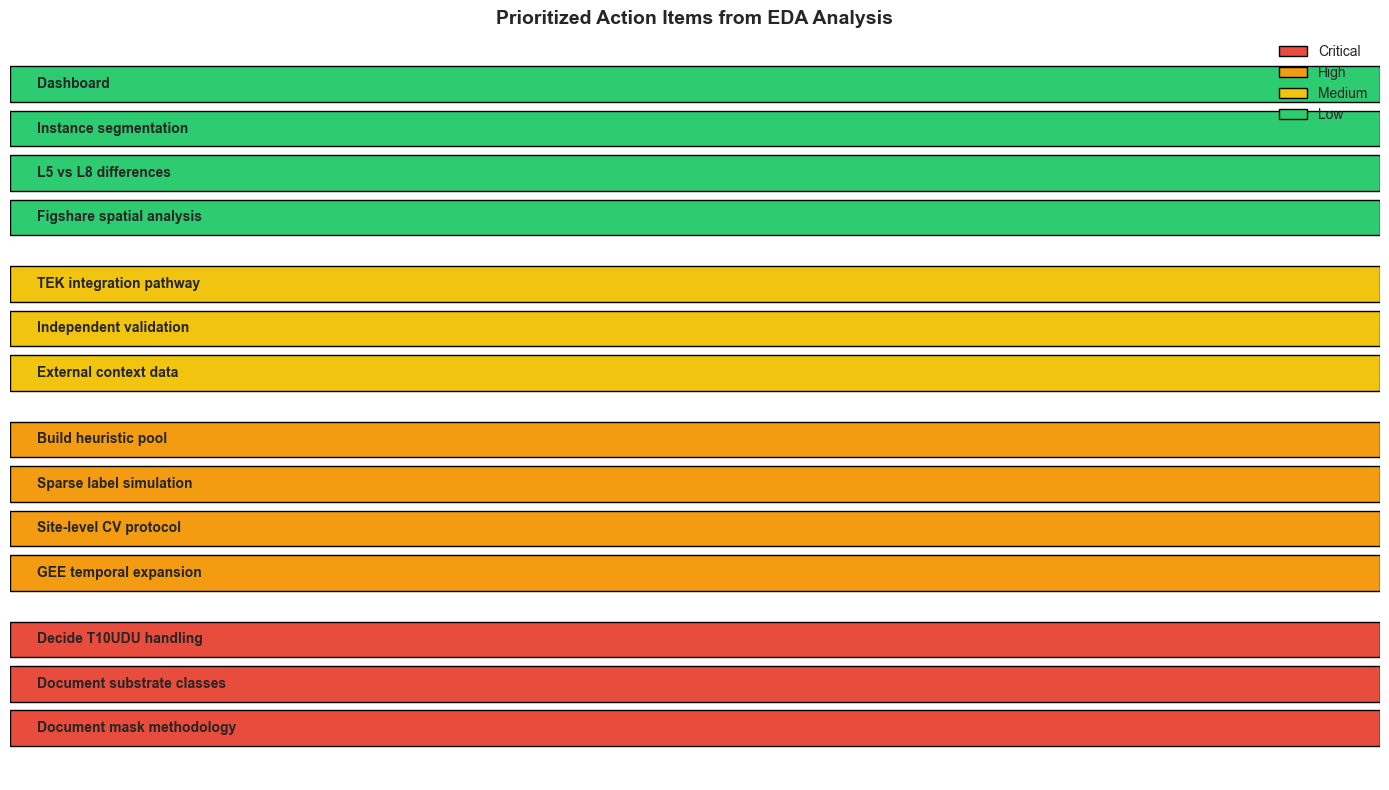

In [28]:
# =============================================================================
# ACTIONABLE RECOMMENDATIONS: PRIORITY RANKED
# =============================================================================

print("="*80)
print("ACTIONABLE RECOMMENDATIONS: PRIORITY RANKED BY IMPACT")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                  CRITICAL PRIORITY (Must Address Before Phase 1)              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔴 CP1. DOCUMENT BC MASK ANNOTATION METHODOLOGY                              ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: Unknown how ground truth masks were created                          ║
║  Risk: If threshold-based, creates circularity with spectral index methods   ║
║  Action: Contact data source, document methodology, add to data_manifest.json║
║  Owner: Researcher / Data Provider                                           ║
║                                                                              ║
║  🔴 CP2. DOCUMENT SUBSTRATE CLASS DEFINITIONS                                 ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: Substrate has 4 classes (1-4) with no legend                         ║
║  Risk: Cannot interpret context-aware results without class meanings         ║
║  Action: Identify source, document classes, add to data_manifest.json        ║
║  Owner: Researcher / Data Provider                                           ║
║                                                                              ║
║  🔴 CP3. DECIDE T10UDU (VICTORIA) HANDLING                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: Missing bathymetry and substrate auxiliary layers                    ║
║  Options: (a) Exclude from context-aware experiments                         ║
║           (b) Source from Canadian Hydrographic Service                      ║
║           (c) Use as "missing data" test case                                ║
║  Action: Make explicit decision and document rationale                       ║
║  Owner: Researcher                                                           ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                  HIGH PRIORITY (Address in Phase 0.5/1)                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🟠 HP1. EXPAND BC TEMPORAL COVERAGE VIA GEE                                  ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: Only 1 temporal sample per site - cannot test temporal adaptation    ║
║  Target: 10+ images per site across multiple seasons                         ║
║  Action: Implement GEE download pipeline for Phase 0.5                       ║
║  Benefit: Addresses RQ1 temporal adaptation requirements                     ║
║                                                                              ║
║  🟠 HP2. IMPLEMENT SITE-LEVEL CROSS-VALIDATION PROTOCOL                       ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: Tile-based splitting causes data leakage due to spatial correlation  ║
║  Action: Implement leave-one-site-out CV as primary evaluation protocol      ║
║  Benefit: Valid generalization metrics, directly tests RQ2                   ║
║                                                                              ║
║  🟠 HP3. DESIGN SPARSE LABEL SIMULATION PROTOCOL                              ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: No naturally sparse labels for testing Component 3                   ║
║  Action: Create simulation with configurable sparsity (1%, 5%, 10%, etc.)    ║
║  Benefit: Enables rigorous testing of RQ3                                    ║
║                                                                              ║
║  🟠 HP4. BUILD HEURISTIC POOL WITH DIVERSE METHODS                            ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: LA framework needs heuristics to select from                         ║
║  Target: 5+ heuristics: NDVI-threshold, FAI, RGB-UNet, multi-spectral CNN,   ║
║          Otsu thresholding, random forest on spectral features               ║
║  Action: Implement HeuristicPool wrapper class in Phase 1                    ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                  MEDIUM PRIORITY (Address in Phase 2+)                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🟡 MP1. SOURCE EXTERNAL ENVIRONMENTAL CONTEXT DATA                           ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: No tide, SST, wind, turbidity metadata for context features          ║
║  Action: Integrate MODIS SST, tide tables, ERA5 wind data                    ║
║  Benefit: Richer context vectors for Component 2                             ║
║                                                                              ║
║  🟡 MP2. DEVELOP INDEPENDENT VALIDATION DATASET                               ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: Single-source ground truth limits external validity                  ║
║  Action: Partner with DFO/Parks Canada for field-validated sites             ║
║  Benefit: Strengthens publication validity                                   ║
║                                                                              ║
║  🟡 MP3. ESTABLISH TEK INTEGRATION PATHWAY                                    ║
║  ────────────────────────────────────────────────────────────────────────────║
║  Issue: RQ5 requires First Nations community engagement                      ║
║  Action: Identify potential community partners, develop data protocols       ║
║  Benefit: Addresses RQ5, enriches research with traditional knowledge        ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                  LOW PRIORITY (Future Work / Nice to Have)                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🟢 LP1. Analyze Figshare path/row spatial distribution                       ║
║  🟢 LP2. Investigate Landsat 5 vs 8 systematic differences                    ║
║  🟢 LP3. Implement instance segmentation analysis (kelp bed counting)         ║
║  🟢 LP4. Create interactive visualization dashboard for EDA results           ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Priority visualization
priorities = {
    'Critical': ['Document mask methodology', 'Document substrate classes', 'Decide T10UDU handling'],
    'High': ['GEE temporal expansion', 'Site-level CV protocol', 'Sparse label simulation', 'Build heuristic pool'],
    'Medium': ['External context data', 'Independent validation', 'TEK integration pathway'],
    'Low': ['Figshare spatial analysis', 'L5 vs L8 differences', 'Instance segmentation', 'Dashboard']
}

fig, ax = plt.subplots(figsize=(14, 8))

colors = {'Critical': '#e74c3c', 'High': '#f39c12', 'Medium': '#f1c40f', 'Low': '#2ecc71'}
y_pos = 0
y_ticks = []
y_labels = []

for priority, items in priorities.items():
    for i, item in enumerate(items):
        ax.barh(y_pos, 1, color=colors[priority], edgecolor='black', height=0.8)
        ax.text(0.02, y_pos, item, va='center', ha='left', fontsize=10, fontweight='bold')
        y_ticks.append(y_pos)
        y_labels.append('')
        y_pos += 1
    y_pos += 0.5  # Gap between priority groups

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('Prioritized Action Items from EDA Analysis', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=p) for p, c in colors.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'action_priorities.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Executive Summary: Key Bullet Points for Report Writing

In [29]:
# =============================================================================
# EXECUTIVE SUMMARY: BULLET POINTS FOR REPORT WRITING
# =============================================================================

print("="*80)
print("EXECUTIVE SUMMARY: KEY BULLET POINTS FOR THESIS REPORT")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    BC SENTINEL-2 DATASET: KEY FINDINGS                        ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATA COMPOSITION:
• The BC Sentinel-2 dataset comprises 1,045 tiles across 10 distinct coastal 
  sites spanning approximately 500km of British Columbia's coastline, from 
  Victoria (48.4°N) to Haida Gwaii (53.0°N).

• Each tile contains 12 bands: 10 spectral bands (B2-B8A, B11-B12) at 10-20m 
  resolution plus 2 auxiliary layers (Bathymetry and Substrate).

• Temporal coverage is limited to single acquisitions per site between 
  September 2020 and September 2023, restricting temporal adaptation analysis.

CLASS DISTRIBUTION:
• Severe class imbalance exists with overall kelp prevalence of only 0.92%
  (approximately 99% of pixels are non-kelp background).

• Kelp prevalence varies 8-fold across sites, from 0.22% (T10UCA, Discovery 
  Islands) to 1.68% (T09UWT, Central Coast), suggesting site-specific 
  environmental factors influence kelp detectability.

SPECTRAL CHARACTERISTICS:
• NIR bands (B8, B8A) show highest mean values (1,155-1,212 DN), consistent 
  with vegetation signatures where kelp is present.

• Bathymetry ranges from -2,000m to +890m, with kelp concentrated in 
  shallow coastal zones (<30m depth) as expected biologically.

• Substrate classification uses 4 classes, with kelp showing preference 
  for specific substrate types (requires documentation of class definitions).

DATA QUALITY CONCERNS:
• T10UDU (Victoria) lacks Bathymetry and Substrate auxiliary layers, 
  potentially requiring exclusion from context-aware experiments.

• Ground truth mask annotation methodology is undocumented, creating 
  uncertainty about annotation quality and potential circularity with 
  threshold-based detection methods.

• Tile counts are highly variable across sites (25-228 tiles), potentially 
  biasing models toward over-represented sites.

╔══════════════════════════════════════════════════════════════════════════════╗
║                   FIGSHARE LANDSAT DATASET: KEY FINDINGS                      ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATA COMPOSITION:
• The Figshare Landsat dataset contains 421 images from the California coast,
  with pre-defined splits: 317 training, 30 validation, and 74 test images.

• Images are RGB-only (3 bands) at 30m resolution, derived from Landsat 5 TM 
  (165 images, 1984-2012) and Landsat 8 OLI (152 images, 2013-present).

• Consistent 1024×1024 pixel dimensions across all images, covering 
  approximately 30.7km × 30.7km per image.

ANNOTATION CHARACTERISTICS:
• Total of 3,345 polygon annotations across 421 images, averaging 
  approximately 8 kelp bed annotations per image.

• Instance-level VIA polygon annotations enable potential kelp bed counting 
  and fragmentation analysis beyond binary segmentation.

• 95.3% of images contain kelp, contrasting sharply with BC's 0.92% pixel-level
  prevalence, suggesting potential selection bias toward kelp-present scenes.

CROSS-SENSOR CONSIDERATIONS:
• Landsat 5 and 8 have different spectral response functions, potentially 
  affecting cross-sensor model consistency.

• 30m resolution is 3× coarser than Sentinel-2's 10m, complicating direct 
  cross-sensor transfer learning.

• California giant kelp (Macrocystis pyrifera) differs from BC's bull kelp 
  (Nereocystis luetkeana), potentially affecting spectral signatures.

╔══════════════════════════════════════════════════════════════════════════════╗
║                    IMPLICATIONS FOR LA FRAMEWORK                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

HEURISTIC POOL DESIGN:
• BC's 12-band imagery enables diverse spectral heuristics including NDVI, 
  FAI, red-edge ratios, and multi-spectral classifiers.

• Figshare's RGB-only constraint limits heuristic diversity to color-based 
  methods, but provides larger training volume for RGB models.

• Combined dataset usage addresses individual weaknesses: BC provides spectral 
  richness while Figshare provides scene diversity.

CONTEXT-AWARE ADAPTATION (Component 2):
• Bathymetry and Substrate layers provide immediate context features for 
  environment-heuristic mapping (depth, substrate type).

• Missing auxiliary data for T10UDU and all Figshare images requires graceful 
  degradation strategy when context unavailable.

• External context data (SST, tide, turbidity) not currently integrated but 
  would strengthen context feature vectors.

SPARSE LABEL HANDLING (Component 3):
• Both datasets provide dense labels, requiring artificial sparsification 
  to simulate operational sparse feedback scenarios.

• Simulation protocol needed with configurable label availability (1%, 5%, 
  10%, 25%, 50%) and temporal delay patterns.

EXPERIMENTAL DESIGN:
• Leave-one-site-out cross-validation on BC dataset provides 10-fold 
  evaluation that directly tests spatial generalization.

• California→BC transfer experiment provides direct test of cross-ecosystem 
  adaptation, a core LA framework objective.

• Severe class imbalance (0.92% kelp) necessitates IoU/F1 metrics rather 
  than pixel accuracy for meaningful performance assessment.

╔══════════════════════════════════════════════════════════════════════════════╗
║                         CRITICAL GAPS IDENTIFIED                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

TEMPORAL COVERAGE GAP:
• Only 1 temporal observation per BC site prevents testing temporal 
  adaptation, a core component of RQ1.

• Seasonal coverage limited to July-September, biasing toward peak kelp 
  season and limiting year-round applicability.

• MITIGATION: Phase 0.5 Google Earth Engine expansion to acquire 10+ 
  images per site with seasonal variation.

ANNOTATION QUALITY GAP:
• BC mask annotation methodology undocumented (manual vs. threshold-based?).

• No inter-annotator agreement metrics or uncertainty quantification.

• Single ground truth source limits external validity of evaluations.

• MITIGATION: Document annotation methodology; seek independent validation 
  from DFO/Parks Canada field surveys.

CONTEXT DATA GAP:
• Environmental metadata (tide height, SST, turbidity, wind) not integrated 
  with imagery timestamps.

• Figshare lacks any auxiliary or location data.

• MITIGATION: Integrate MODIS SST, tide tables, ERA5 reanalysis for BC sites.

TEK INTEGRATION GAP:
• No First Nations community data sources currently identified.

• RQ5 (Traditional Ecological Knowledge integration) requires partnership 
  development beyond current dataset scope.

• MITIGATION: Initiate community engagement in parallel with technical 
  development.
""")

# Final summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS TABLE")
print("="*80)
summary_table = pd.DataFrame({
    'Metric': ['Total Samples', 'Spectral Bands', 'Spatial Resolution', 
               'Geographic Coverage', 'Temporal Coverage', 'Kelp Prevalence',
               'Auxiliary Data', 'Annotation Format'],
    'BC Sentinel-2': ['1,045 tiles', '12 bands', '10m', 
                      '10 sites (500km coast)', '1 date per site (2020-2023)',
                      '0.92%', 'Bathymetry, Substrate', 'Binary raster masks'],
    'Figshare Landsat': ['421 images', '3 bands (RGB)', '30m',
                         'California coast', '1984-2020+ (multi-year)',
                         '95.3% (presence)', 'None', 'VIA polygon JSON']
})
print(summary_table.to_string(index=False))

# Save summary
print(f"\n>>> EDA notebook complete. Outputs saved to: {OUTPUT_DIR}")

EXECUTIVE SUMMARY: KEY BULLET POINTS FOR THESIS REPORT

╔══════════════════════════════════════════════════════════════════════════════╗
║                    BC SENTINEL-2 DATASET: KEY FINDINGS                        ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATA COMPOSITION:
• The BC Sentinel-2 dataset comprises 1,045 tiles across 10 distinct coastal 
  sites spanning approximately 500km of British Columbia's coastline, from 
  Victoria (48.4°N) to Haida Gwaii (53.0°N).

• Each tile contains 12 bands: 10 spectral bands (B2-B8A, B11-B12) at 10-20m 
  resolution plus 2 auxiliary layers (Bathymetry and Substrate).

• Temporal coverage is limited to single acquisitions per site between 
  September 2020 and September 2023, restricting temporal adaptation analysis.

CLASS DISTRIBUTION:
• Severe class imbalance exists with overall kelp prevalence of only 0.92%
  (approximately 99% of pixels are non-kelp background).

• Kelp prevalence varies 8-fold 

In [30]:
# Generate summary
print("="*60)
print("EDA SUMMARY")
print("="*60)
print()
print("BC Sentinel-2 Dataset:")
print(f"  - Total scenes: {manifest['summary']['total_scenes']}")
print(f"  - Total tiles: {manifest['summary']['total_tiles']}")
print(f"  - Bands: 12 (10 spectral + 2 auxiliary)")
print(f"  - Tile size: 512×512")
print(f"  - Mean kelp prevalence: {prevalence_df['kelp_pct'].mean():.2f}%")
print()
print("Figshare Landsat Dataset:")
print(f"  - Total images: {split_df['n_images'].sum()}")
print(f"  - Splits: train={split_df[split_df['split']=='train']['n_images'].values[0]}, "
      f"val={split_df[split_df['split']=='val']['n_images'].values[0]}, "
      f"test={split_df[split_df['split']=='test']['n_images'].values[0]}")
print(f"  - Bands: 3 (RGB)")
print(f"  - Annotation format: VIA polygons")
print()
print("Next Steps:")
print("  1. Convert VIA annotations to binary masks")
print("  2. Create unified PyTorch data loaders")
print("  3. Generate 4K sample maps for publication")
print("="*60)

EDA SUMMARY

BC Sentinel-2 Dataset:
  - Total scenes: 10
  - Total tiles: 1045
  - Bands: 12 (10 spectral + 2 auxiliary)
  - Tile size: 512×512
  - Mean kelp prevalence: 0.92%

Figshare Landsat Dataset:
  - Total images: 421
  - Splits: train=317, val=30, test=74
  - Bands: 3 (RGB)
  - Annotation format: VIA polygons

Next Steps:
  1. Convert VIA annotations to binary masks
  2. Create unified PyTorch data loaders
  3. Generate 4K sample maps for publication


In [31]:
# Save summary statistics
summary = {
    'bc_sentinel2': {
        'total_scenes': manifest['summary']['total_scenes'],
        'total_tiles': manifest['summary']['total_tiles'],
        'mean_kelp_pct': float(prevalence_df['kelp_pct'].mean()),
        'band_stats': stats_df.to_dict('records')
    },
    'figshare_landsat': {
        'total_images': int(split_df['n_images'].sum()),
        'splits': split_df.to_dict('records')
    }
}

with open(OUTPUT_DIR / 'eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to: {OUTPUT_DIR / 'eda_summary.json'}")

Summary saved to: /Users/ebisong/Documents/code/uvic/thesis/results/raw/phase_0_eda/eda_summary.json
